# 4/24 진행 내역
1. XGBoost x Catboost 앙상블 진행
2. XGBoost optuna / Catboost optuna 진행
3. XGBoost x Catboost optuna 앙상블 진행

### 결론
1. XGBoost와 CatBoost가 같은 피처, 같은 데이터, 비슷한 트리 구조를 사용하기 때문에 다양성 확보가 어려움
2. 다른 모델을 섞어서 진행할 필요가 있음

# 실험 로그

| 실험 | 모델 | Feature Engineering | 파라미터 | Score | 비고 |
|------|------|---------------------|----------|-------|------|
| exp1 | XGBoost | 기본 feature + 파생변수 110개 | lr=0.05, depth=6, subsample=0.8 | 0.7392 | |
| exp2 | Catboost | - | iterations=2000, lr=0.05, depth=6 | 0.7397 | |
| exp3 | XGBoost x Catboost 앙상블 | 기본 feature + 파생변수 110개 | iterations=2000, lr=0.05, depth=6  | 0.7399 | A. Simple Average (XGB : Cat = 1:1) |
| exp4 | - |  -  |  - | 0.7399 | B. Weighted Average(OOF AUC가 높은 모델 가중치 부여) |
| exp5 | - |  -  |  - | 0.7399 | C. Stacking (메타 모델 : LR) |
| exp6 | - |  -  |  - | 0.7399 | D. Rank Average(확률 대신 순위로 변환 후 평균) |
| exp7 | XGBoost | 기본 feature + 파생변수 110개 | XGB: depth=5 / Cat: depth=5  | 0.7397 |optuna|
| exp8 | Catboost | - | XGB: depth=5 / Cat: depth=5  | 0.7397 |optuna |
| exp7 | XGBoost x Catboost 앙상블(optuna) |  기본 feature + 파생변수 110개  | XGB: depth=5 / Cat: depth=5 | 0.7399 | A. Simple Average (XGB : Cat = 1:1) |
| exp8 | - |  -  |  - | 0.7399 | B. Weighted Average(OOF AUC가 높은 모델 가중치 부여) |
| exp9 | - |  -  |  - | 0.7399 | C. Stacking (메타 모델 : LR) |
| exp10 | - |  -  |  - | 0.7399 | D. Rank Average(확률 대신 순위로 변환 후 평균) |

In [1]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 4.8 MB/s eta 0:00:00


In [26]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [3]:
# 한글 폰트 설정
!pip install koreanize-matplotlib -q

try:
    import koreanize_matplotlib
except ImportError:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 17.9 MB/s eta 0:00:00


In [4]:
#시드 고정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [5]:
TARGET = "임신 성공 여부"
ID_COL = "ID"
DATA_DIR = Path(".")   # 데이터 경로 수정

SEED = 42

In [6]:
train = pd.read_csv(DATA_DIR / "train.csv", encoding="utf-8-sig")
test  = pd.read_csv(DATA_DIR / "test.csv",  encoding="utf-8-sig")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv", encoding="utf-8-sig")

train.columns = [c.strip() for c in train.columns]
test.columns  = [c.strip() for c in test.columns]

df = train.copy()   # EDA용 원본 복사본

print(f"  Train shape : {train.shape}")
print(f"  Test  shape : {test.shape}")
print(f"\n  타겟 분포:\n{train[TARGET].value_counts()}")
print(f"\n  양성 비율: {train[TARGET].mean():.4f}")

  Train shape : (256351, 69)
  Test  shape : (90067, 68)

  타겟 분포:
임신 성공 여부
0    190123
1     66228
Name: count, dtype: int64

  양성 비율: 0.2583


단변량 분석

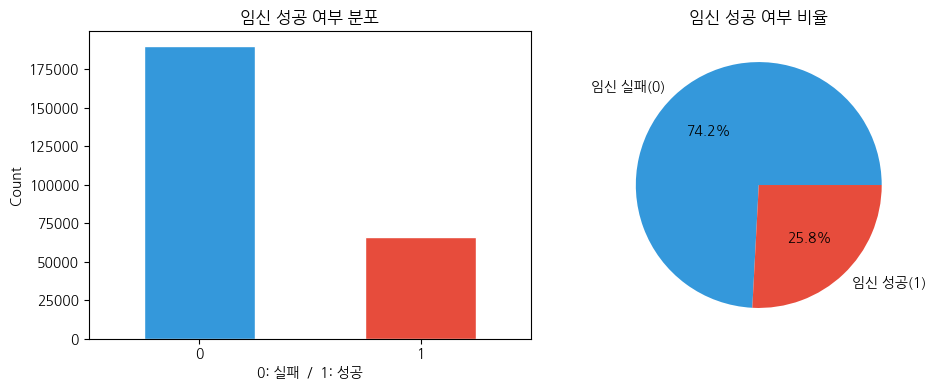

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
train[TARGET].value_counts().plot(
    kind="bar", ax=axes[0],
    color=["#3498db", "#e74c3c"], edgecolor="white"
)
axes[0].set_title("임신 성공 여부 분포")
axes[0].set_xlabel("0: 실패  /  1: 성공")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

train[TARGET].value_counts().plot(
    kind="pie", ax=axes[1],
    labels=["임신 실패(0)", "임신 성공(1)"],
    autopct="%1.1f%%", colors=["#3498db", "#e74c3c"]
)
axes[1].set_title("임신 성공 여부 비율")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


  전처리 전 결측치 현황 (Train)  (결측 컬럼: 31개 / 전체: 67개)
  🔴 난자 해동 경과일                        254,915건   99.4%  float64     컬럼 제거
  🔴 PGS 시술 여부                        254,422건   99.2%  float64     컬럼 제거
  🔴 PGD 시술 여부                        254,172건   99.1%  float64     컬럼 제거
  🔴 착상 전 유전 검사 사용 여부                 253,633건   98.9%  float64     컬럼 제거
  🔴 임신 시도 또는 마지막 임신 경과 연수            246,981건   96.3%  float64     컬럼 제거
  🔴 배아 해동 경과일                        215,982건   84.3%  float64     컬럼 제거
  🟠 난자 채취 경과일                        57,488건   22.4%  float64     중앙값 대체
  🟠 난자 혼합 경과일                        53,735건   21.0%  float64     중앙값 대체
  🟡 배아 이식 경과일                        43,566건   17.0%  float64     중앙값 대체
  🟡 저장된 배아 수                          6,291건    2.5%  float64     중앙값 대체
  🟡 단일 배아 이식 여부                       6,291건    2.5%  float64     중앙값 대체
  🟡 배아 생성 주요 이유                       6,291건    2.5%  object      최빈값 대체
  🟡 착상 전 유전 진단 사용 여부                  6,291건    2.5%  float64     중앙값 대체
  🟡

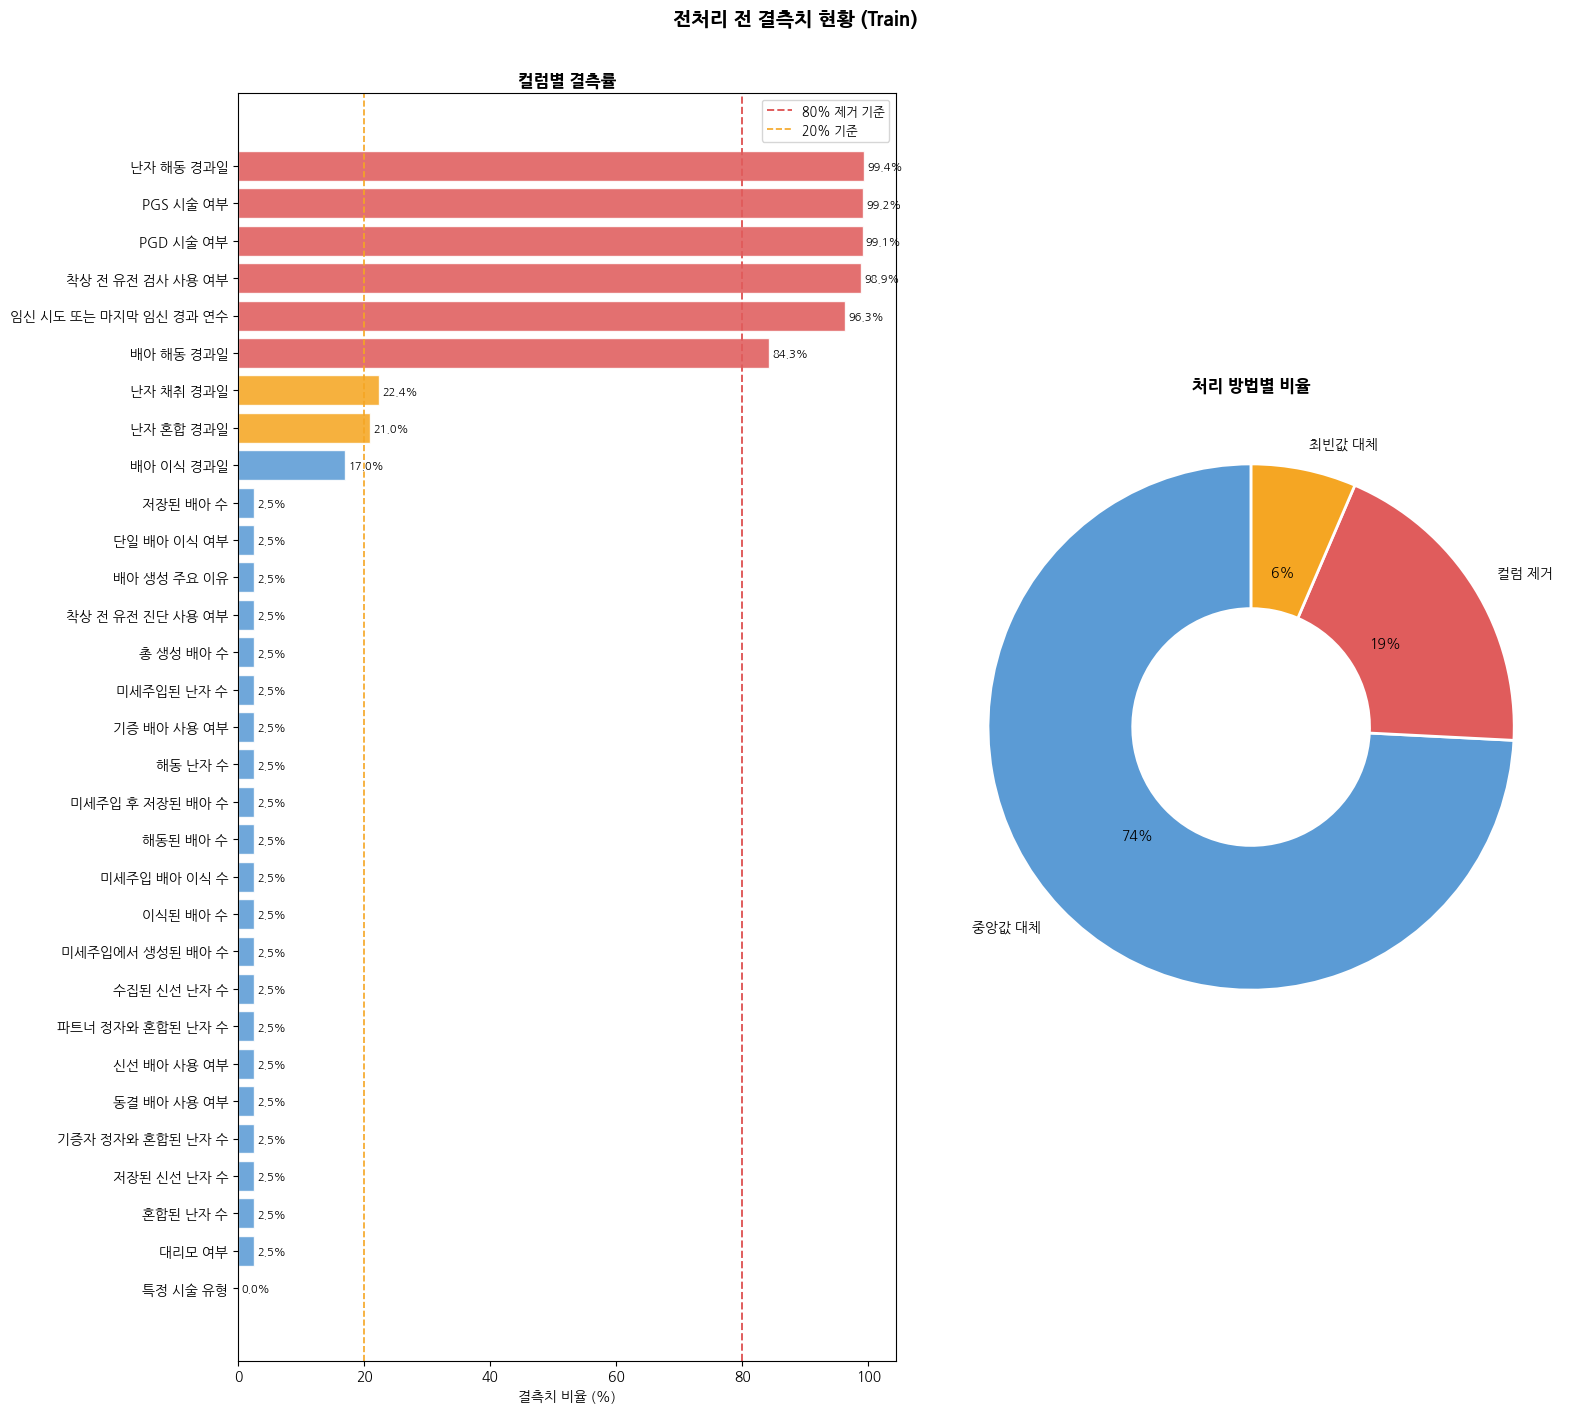

,컬럼명,결측 수,결측률(%),타입,처리 방법
0,난자 해동 경과일,254915,99.4,float64,컬럼 제거
1,PGS 시술 여부,254422,99.2,float64,컬럼 제거
2,PGD 시술 여부,254172,99.1,float64,컬럼 제거
3,착상 전 유전 검사 사용 여부,253633,98.9,float64,컬럼 제거
4,임신 시도 또는 마지막 임신 경과 연수,246981,96.3,float64,컬럼 제거
5,배아 해동 경과일,215982,84.3,float64,컬럼 제거
6,난자 채취 경과일,57488,22.4,float64,중앙값 대체
7,난자 혼합 경과일,53735,21.0,float64,중앙값 대체
8,배아 이식 경과일,43566,17.0,float64,중앙값 대체
9,저장된 배아 수,6291,2.5,float64,중앙값 대체


In [8]:
def show_missing_summary(df, title="결측치 현황"):
    missing     = df.isnull().sum()
    missing     = missing[missing > 0].sort_values(ascending=False)
    missing_pct = (missing / len(df) * 100).round(1)
    dtypes      = df.dtypes[missing.index].astype(str)

    def get_method(col, pct):
        if pct >= 80:
            return "컬럼 제거"
        elif col in ["난자 채취 경과일", "난자 혼합 경과일", "배아 이식 경과일"]:
            return "중앙값 대체"
        elif df[col].dtype == object:
            return "최빈값 대체"
        else:
            return "중앙값 대체" if "float" in str(df[col].dtype) else "최빈값 대체"

    methods = [get_method(col, pct) for col, pct in missing_pct.items()]

    summary = pd.DataFrame({
        "컬럼명"    : missing.index,
        "결측 수"   : missing.values,
        "결측률(%)": missing_pct.values,
        "타입"      : dtypes.values,
        "처리 방법" : methods,
    }).reset_index(drop=True)

    print(f"\n{'='*72}")
    print(f"  {title}  (결측 컬럼: {len(summary)}개 / 전체: {df.shape[1]}개)")
    print(f"{'='*72}")
    for _, row in summary.iterrows():
        flag = "🔴" if row["결측률(%)"] >= 80 else "🟠" if row["결측률(%)"] >= 20 else "🟡"
        print(f"  {flag} {row['컬럼명']:<32} {int(row['결측 수']):>6,}건  "
              f"{row['결측률(%)']:>5.1f}%  {row['타입']:<10}  {row['처리 방법']}")
    print(f"{'='*72}")

    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(summary) * 0.45)))
    colors = ["#E05C5C" if p >= 80 else "#F5A623" if p >= 20 else "#5B9BD5"
              for p in summary["결측률(%)"]]
    axes[0].barh(summary["컬럼명"][::-1], summary["결측률(%)"][::-1],
                 color=colors[::-1], alpha=0.88, edgecolor="white")
    axes[0].axvline(80, color="#E05C5C", linestyle="--", linewidth=1.4, label="80% 제거 기준")
    axes[0].axvline(20, color="#F5A623", linestyle="--", linewidth=1.2, label="20% 기준")
    for i, val in enumerate(summary["결측률(%)"][::-1]):
        axes[0].text(val + 0.5, i, f"{val:.1f}%", va="center", fontsize=8)
    axes[0].set_xlabel("결측치 비율 (%)")
    axes[0].set_title("컬럼별 결측률", fontweight="bold")
    axes[0].legend(fontsize=9)

    method_counts = summary["처리 방법"].value_counts()
    pie_colors = {"컬럼 제거": "#E05C5C", "중앙값 대체": "#5B9BD5", "최빈값 대체": "#F5A623"}
    axes[1].pie(
        method_counts.values, labels=method_counts.index, autopct="%1.0f%%",
        colors=[pie_colors.get(m, "#AAAAAA") for m in method_counts.index],
        startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2, "width": 0.55},
    )
    axes[1].set_title("처리 방법별 비율", fontweight="bold")
    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    return summary


# train에서 ID, 타겟 제외하고 결측 확인
show_missing_summary(
    train.drop(columns=[ID_COL, TARGET], errors="ignore"),
    "전처리 전 결측치 현황 (Train)"
)


  수치형 변수 이상치 현황 (IQR 기준)
                  최솟값   Q1  중앙값    Q3   최댓값  이상치 수  이상치율(%)    하한    상한
컬럼명                                                                    
총 생성 배아 수         0.0  1.0  4.0   8.0  51.0   3312      1.3  -9.5  18.5
미세주입된 난자 수        0.0  0.0  0.0   7.0  51.0   7511      3.0 -10.5  17.5
미세주입에서 생성된 배아 수   0.0  0.0  0.0   5.0  43.0   8524      3.4  -7.5  12.5
이식된 배아 수          0.0  1.0  1.0   2.0   3.0      0      0.0  -0.5   3.5
저장된 배아 수          0.0  0.0  0.0   2.0  51.0  14218      5.7  -3.0   5.0
수집된 신선 난자 수       0.0  2.0  8.0  13.0  51.0   2733      1.1 -14.5  29.5
혼합된 난자 수          0.0  3.0  7.0  11.0  51.0   5314      2.1  -9.0  23.0
파트너 정자와 혼합된 난자 수  0.0  0.0  6.0  11.0  51.0   2035      0.8 -16.5  27.5
배아 이식 경과일         0.0  2.0  3.0   5.0   7.0      0      0.0  -2.5   9.5
난자 혼합 경과일         0.0  0.0  0.0   0.0   7.0    696      0.3   0.0   0.0


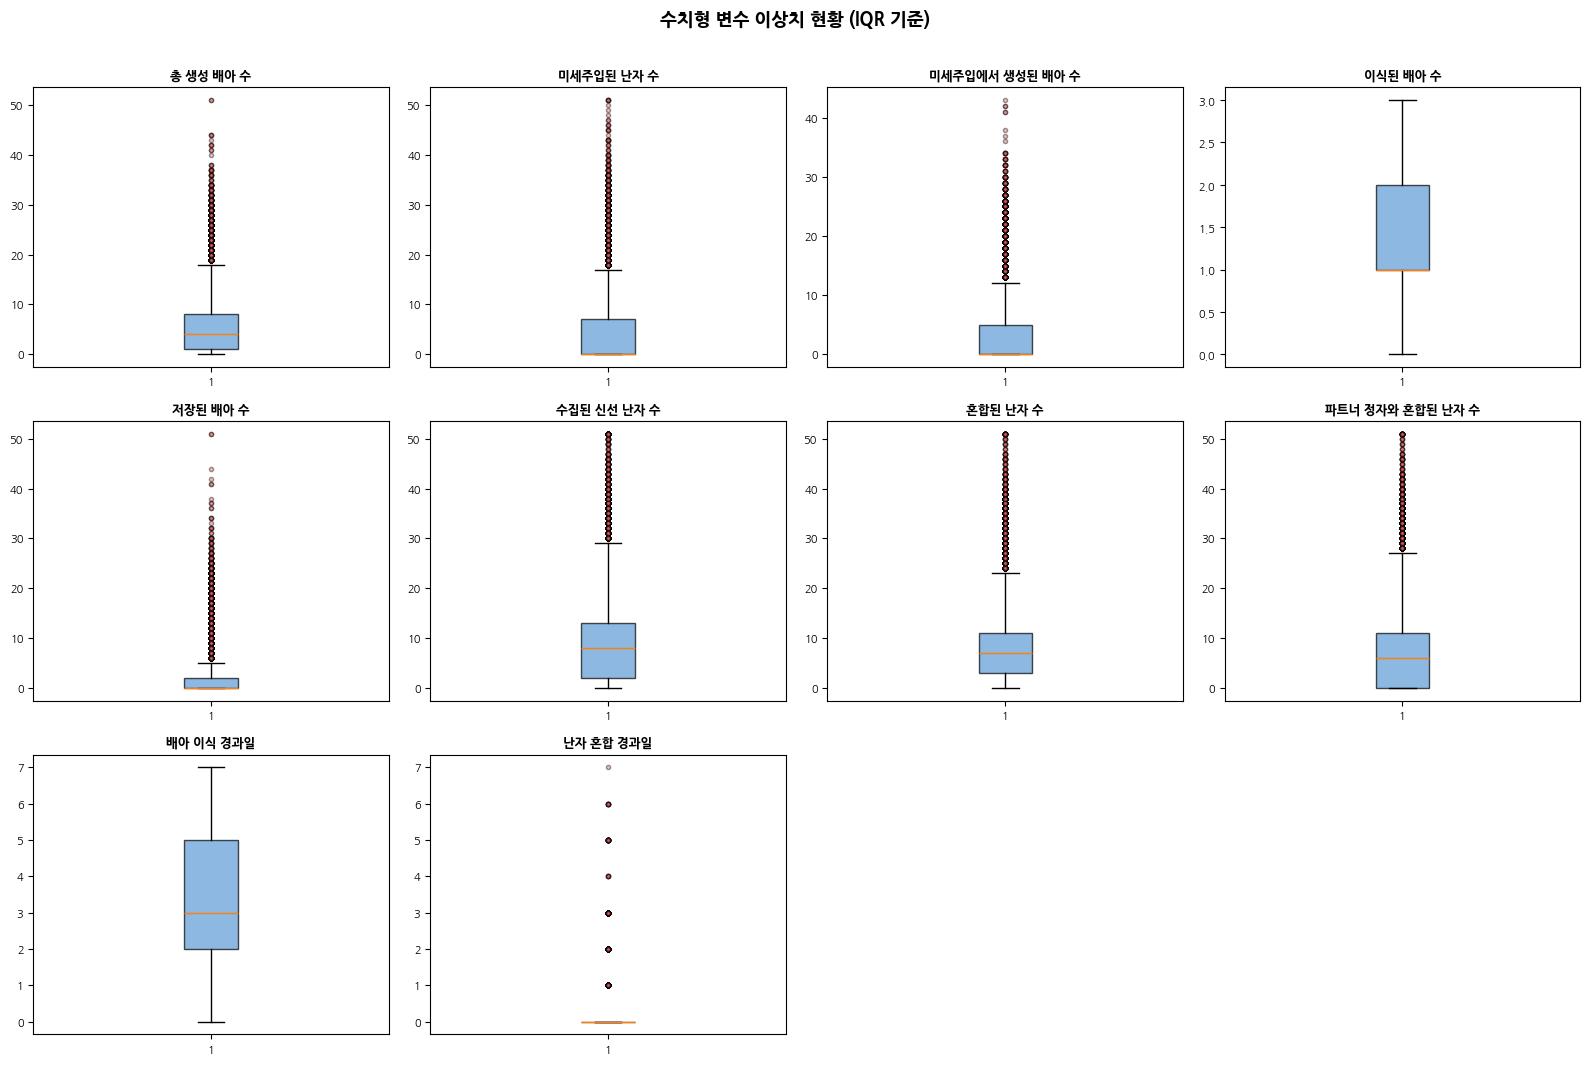

,컬럼명,최솟값,Q1,중앙값,Q3,최댓값,이상치 수,이상치율(%),하한,상한
0,총 생성 배아 수,0.0,1.0,4.0,8.0,51.0,3312,1.3,-9.5,18.5
1,미세주입된 난자 수,0.0,0.0,0.0,7.0,51.0,7511,3.0,-10.5,17.5
2,미세주입에서 생성된 배아 수,0.0,0.0,0.0,5.0,43.0,8524,3.4,-7.5,12.5
3,이식된 배아 수,0.0,1.0,1.0,2.0,3.0,0,0.0,-0.5,3.5
4,저장된 배아 수,0.0,0.0,0.0,2.0,51.0,14218,5.7,-3.0,5.0
5,수집된 신선 난자 수,0.0,2.0,8.0,13.0,51.0,2733,1.1,-14.5,29.5
6,혼합된 난자 수,0.0,3.0,7.0,11.0,51.0,5314,2.1,-9.0,23.0
7,파트너 정자와 혼합된 난자 수,0.0,0.0,6.0,11.0,51.0,2035,0.8,-16.5,27.5
8,배아 이식 경과일,0.0,2.0,3.0,5.0,7.0,0,0.0,-2.5,9.5
9,난자 혼합 경과일,0.0,0.0,0.0,0.0,7.0,696,0.3,0.0,0.0


In [9]:
def check_outliers(df, cols, title="이상치 현황 (IQR 기준)"):
    records = []
    for col in cols:
        if col not in df.columns:
            continue
        d = df[col].dropna()
        Q1, Q3 = d.quantile(0.25), d.quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        out_cnt = ((d < lower) | (d > upper)).sum()
        records.append({
            "컬럼명"    : col,
            "최솟값"    : d.min(),  "Q1": Q1, "중앙값": d.median(),
            "Q3"        : Q3,       "최댓값": d.max(),
            "이상치 수" : out_cnt,
            "이상치율(%)": round(out_cnt / len(d) * 100, 1),
            "하한"      : round(lower, 1), "상한": round(upper, 1),
        })

    summary = pd.DataFrame(records)
    print(f"\n{'='*72}\n  {title}\n{'='*72}")
    print(summary.set_index("컬럼명").to_string())

    n_cols = 4
    n_rows = (len(cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5))
    axes = axes.flatten()
    valid_cols = [c for c in cols if c in df.columns]
    for i, col in enumerate(valid_cols):
        data = df[col].dropna()
        bp = axes[i].boxplot(data, vert=True, patch_artist=True,
                             flierprops=dict(marker="o", markersize=3,
                                             markerfacecolor="#E05C5C", alpha=0.4))
        bp["boxes"][0].set_facecolor("#5B9BD5")
        bp["boxes"][0].set_alpha(0.7)
        axes[i].set_title(col, fontsize=9, fontweight="bold")
        axes[i].tick_params(labelsize=8)
    for j in range(len(valid_cols), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    return summary


NUM_COLS = [
    "총 생성 배아 수", "미세주입된 난자 수", "미세주입에서 생성된 배아 수",
    "이식된 배아 수", "저장된 배아 수", "수집된 신선 난자 수",
    "혼합된 난자 수", "파트너 정자와 혼합된 난자 수",
    "배아 이식 경과일", "난자 혼합 경과일",
]
check_outliers(
    train.drop(columns=[ID_COL, TARGET], errors="ignore"),
    NUM_COLS, "수치형 변수 이상치 현황 (IQR 기준)"
)


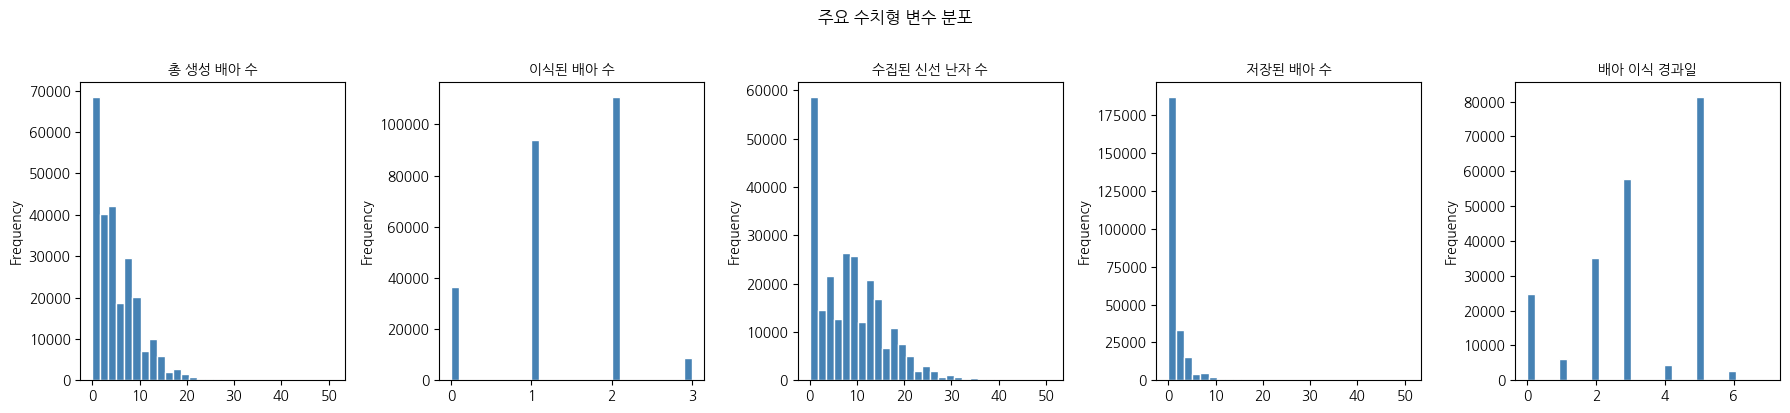

In [10]:
num_cols_view = ["총 생성 배아 수", "이식된 배아 수", "수집된 신선 난자 수",
                 "저장된 배아 수", "배아 이식 경과일"]
fig, axes = plt.subplots(1, len(num_cols_view), figsize=(18, 4))
for ax, col in zip(axes, num_cols_view):
    train[col].dropna().plot(kind="hist", bins=30, ax=ax,
                             color="steelblue", edgecolor="white")
    ax.set_title(col, fontsize=10)
plt.suptitle("주요 수치형 변수 분포", y=1.02)
plt.tight_layout()
plt.show()

In [11]:
AGE_MAP = {
    "만18-34세": 0, "만35-37세": 1, "만38-39세": 2,
    "만40-42세": 3, "만43-44세": 4, "만45-50세": 5,
    "알 수 없음": -1,
}
COUNT_MAP = {"0회": 0, "1회": 1, "2회": 2, "3회": 3, "4회": 4, "5회": 5, "6회 이상": 6}
DONOR_AGE_MAP = {
    "만20세 이하": 0, "만21-25세": 1, "만26-30세": 2,
    "만31-35세": 3,  "만36-40세": 4, "만41-45세": 5,
    "알 수 없음": -1,
}
COUNT_COLS = [
    "총 시술 횟수", "클리닉 내 총 시술 횟수",
    "IVF 시술 횟수", "DI 시술 횟수",
    "총 임신 횟수", "IVF 임신 횟수", "DI 임신 횟수",
    "총 출산 횟수", "IVF 출산 횟수", "DI 출산 횟수",
]

In [12]:
DROP_COLS = [
    "착상 전 유전 검사 사용 여부",   # 98.94% 결측, 비결측값 모두 1.0
    "PGD 시술 여부",                 # 99.15% 결측
    "PGS 시술 여부",                 # 99.25% 결측
    "불임 원인 - 여성 요인",          # zero variance
    "난자 채취 경과일",               # zero variance
    "난자 해동 경과일",               # 99.44% 결측
]

In [13]:
REASON_CATEGORIES = ["현재 시술용", "배아 저장용", "난자 저장용", "기증용", "연구용"]
PROCEDURE_TYPES   = ["IVF", "ICSI", "IUI", "ICI", "GIFT", "FER",
                     "BLASTOCYST", "AH", "Generic DI", "IVI"]

def expand_reason(df):
    col = "배아 생성 주요 이유"
    for cat in REASON_CATEGORIES:
        df[f"이유_{cat}"] = df[col].fillna("").str.contains(cat).astype(int)
    return df

def expand_procedure(df):
    col = "특정 시술 유형"
    filled = df[col].fillna("Unknown")
    for pt in PROCEDURE_TYPES:
        df[f"시술_{pt}"] = (
            filled.str.upper().str.replace(" ", "", regex=False)
            .str.contains(pt.upper()).astype(int)
        )
    return df

In [14]:
def preprocess(df: pd.DataFrame, fit_label_encoders=None) -> tuple:
    df = df.copy()

    # 컬럼 제거
    df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

    # 임신 시도 연수 (96% 결측) → 결측 지시 변수 + -1 대체
    col_years = "임신 시도 또는 마지막 임신 경과 연수"
    if col_years in df.columns:
        df["임신_시도_연수_결측"] = df[col_years].isnull().astype(int)
        df[col_years] = df[col_years].fillna(-1)

    # 배아 해동 경과일 (84% 결측) → 결측 지시 변수 + 0 대체
    col_thaw = "배아 해동 경과일"
    if col_thaw in df.columns:
        df["배아_해동_결측"] = df[col_thaw].isnull().astype(int)
        df[col_thaw] = df[col_thaw].fillna(0)

    # DI 시술행 IVF 전용 컬럼 → 0 대체
    FILL_ZERO_COLS = [
        "단일 배아 이식 여부", "착상 전 유전 진단 사용 여부", "배아 생성 주요 이유",
        "총 생성 배아 수", "미세주입된 난자 수", "미세주입에서 생성된 배아 수",
        "이식된 배아 수", "미세주입 배아 이식 수", "저장된 배아 수",
        "미세주입 후 저장된 배아 수", "해동된 배아 수", "해동 난자 수",
        "수집된 신선 난자 수", "저장된 신선 난자 수", "혼합된 난자 수",
        "파트너 정자와 혼합된 난자 수", "기증자 정자와 혼합된 난자 수",
        "동결 배아 사용 여부", "신선 배아 사용 여부", "기증 배아 사용 여부", "대리모 여부",
    ]
    for col in FILL_ZERO_COLS:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # 경과일 컬럼 중앙값 대체
    for col in ["난자 혼합 경과일", "배아 이식 경과일"]:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # 순서형 인코딩: 나이
    if "시술 당시 나이" in df.columns:
        df["시술 당시 나이"] = df["시술 당시 나이"].map(AGE_MAP).fillna(-1).astype(int)

    # 순서형 인코딩: 횟수 컬럼
    for col in COUNT_COLS:
        if col in df.columns:
            df[col] = df[col].map(COUNT_MAP).fillna(-1).astype(int)

    # 순서형 인코딩: 기증자 나이
    for col in ["난자 기증자 나이", "정자 기증자 나이"]:
        if col in df.columns:
            df[col] = df[col].map(DONOR_AGE_MAP).fillna(-1).astype(int)

    # 시술 유형 이진화 (IVF=1, DI=0)
    if "시술 유형" in df.columns:
        df["시술 유형"] = (df["시술 유형"] == "IVF").astype(int)

    # 배란 유도 유형 인코딩
    induction_map = {
        "알 수 없음": 0, "기록되지 않은 시행": 1,
        "생식선 자극 호르몬": 2, "세트로타이드 (억제제)": 3,
    }
    if "배란 유도 유형" in df.columns:
        df["배란 유도 유형"] = df["배란 유도 유형"].map(induction_map).fillna(0).astype(int)

    # 난자/정자 출처 인코딩
    egg_map   = {"본인 제공": 0, "기증 제공": 1, "알 수 없음": -1}
    sperm_map = {"배우자 제공": 0, "기증 제공": 1, "배우자 및 기증 제공": 2, "미할당": -1}
    if "난자 출처" in df.columns:
        df["난자 출처"] = df["난자 출처"].map(egg_map).fillna(-1).astype(int)
    if "정자 출처" in df.columns:
        df["정자 출처"] = df["정자 출처"].map(sperm_map).fillna(-1).astype(int)

    # 시술 시기 코드 레이블 인코딩
    code_map = {v: i for i, v in enumerate(
        ["TRCMWS", "TRDQAZ", "TRJXFG", "TRVNRY", "TRXQMD", "TRYBLT", "TRZKPL"]
    )}
    if "시술 시기 코드" in df.columns:
        df["시술 시기 코드"] = df["시술 시기 코드"].map(code_map).fillna(-1).astype(int)

    # 레이블 인코딩: 명목형 범주  ← project_1.ipynb
    LABEL_ENC_COLS = ["배아 생성 주요 이유", "특정 시술 유형"]
    label_encoders = fit_label_encoders or {}
    for col in LABEL_ENC_COLS:
        if col not in df.columns:
            continue
        if col not in label_encoders:
            le = LabelEncoder()
            le.fit(df[col].fillna("Unknown").astype(str))
            label_encoders[col] = le
        df[col] = label_encoders[col].transform(df[col].fillna("Unknown").astype(str))

    # 이진 컬럼 결측 → 0
    binary_cols = [
        "배란 자극 여부", "단일 배아 이식 여부", "착상 전 유전 진단 사용 여부",
        "남성 주 불임 원인", "남성 부 불임 원인",
        "여성 주 불임 원인", "여성 부 불임 원인",
        "부부 주 불임 원인", "부부 부 불임 원인", "불명확 불임 원인",
        "불임 원인 - 난관 질환", "불임 원인 - 남성 요인", "불임 원인 - 배란 장애",
        "불임 원인 - 자궁경부 문제", "불임 원인 - 자궁내막증",
        "불임 원인 - 정자 농도", "불임 원인 - 정자 면역학적 요인",
        "불임 원인 - 정자 운동성", "불임 원인 - 정자 형태",
        "동결 배아 사용 여부", "신선 배아 사용 여부",
        "기증 배아 사용 여부", "대리모 여부",
    ]
    for c in binary_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int)

    # 연속형 수치 결측 → 중앙값
    cont_cols = [
        "총 생성 배아 수", "미세주입된 난자 수", "미세주입에서 생성된 배아 수",
        "이식된 배아 수", "미세주입 배아 이식 수",
        "저장된 배아 수", "미세주입 후 저장된 배아 수",
        "해동된 배아 수", "해동 난자 수",
        "수집된 신선 난자 수", "저장된 신선 난자 수",
        "혼합된 난자 수", "파트너 정자와 혼합된 난자 수", "기증자 정자와 혼합된 난자 수",
        "난자 혼합 경과일", "배아 이식 경과일", "배아 해동 경과일",
    ]
    for c in cont_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
            df[c] = df[c].fillna(df[c].median() if df[c].notna().any() else -1)

    return df, label_encoders


# 멀티레이블 분리는 전처리 전에 적용
def preprocess_full(df, fit_label_encoders=None):
    df = expand_reason(df.copy())
    df = expand_procedure(df)
    df.drop(columns=["배아 생성 주요 이유", "특정 시술 유형"],
            inplace=True, errors="ignore")
    df, le = preprocess(df, fit_label_encoders)
    return df, le


X_raw = train.drop(columns=[ID_COL, TARGET], errors="ignore")
y     = train[TARGET]
X_test_raw = test.drop(columns=[ID_COL], errors="ignore")

X_pp, label_encoders = preprocess_full(X_raw)
X_test_pp, _         = preprocess_full(X_test_raw, fit_label_encoders=label_encoders)

print(f"\n  전처리 후 Train shape: {X_pp.shape}")
print(f"  전처리 후 Test  shape: {X_test_pp.shape}")
print(f"  잔여 결측치 (Train): {X_pp.isnull().sum().sum()}")


  전처리 후 Train shape: (256351, 76)
  전처리 후 Test  shape: (90067, 76)
  잔여 결측치 (Train): 0


이변량 분석


In [15]:
AGE_ORDER   = ["만18-34세","만35-37세","만38-39세","만40-42세","만43-44세","만45-50세","알 수 없음"]
COUNT_ORDER = ["0회","1회","2회","3회","4회","5회","6회 이상"]

파생변수

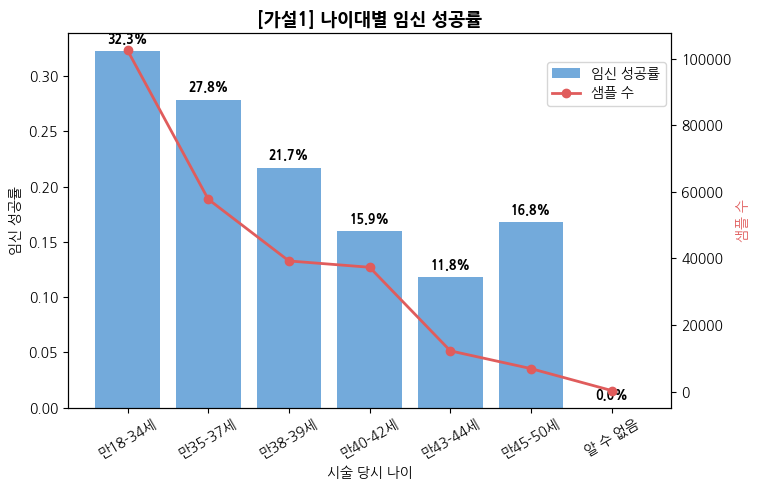

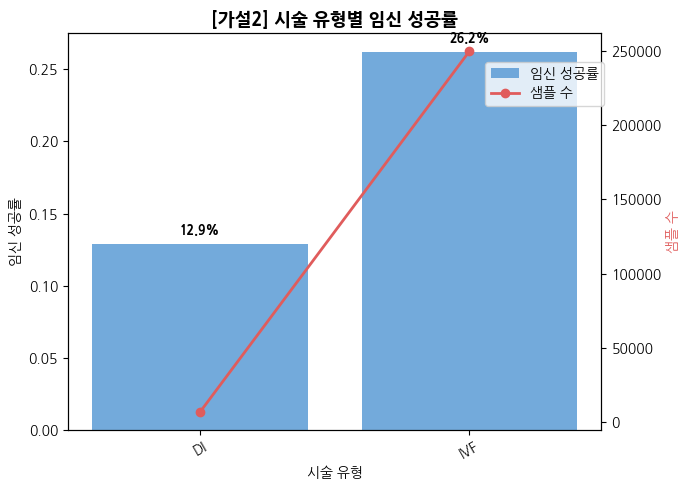

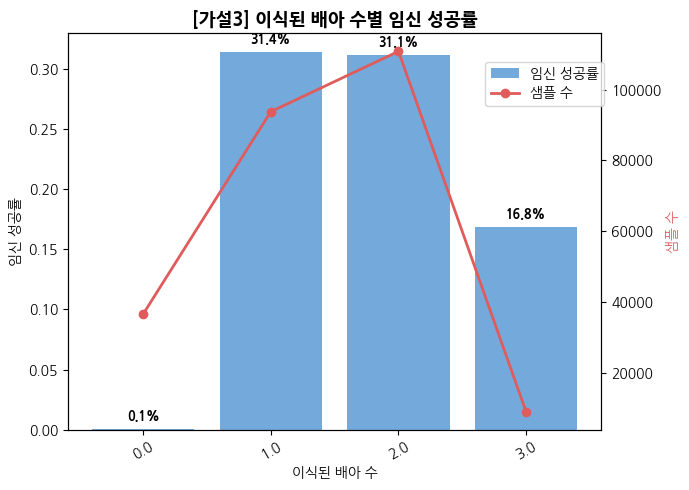

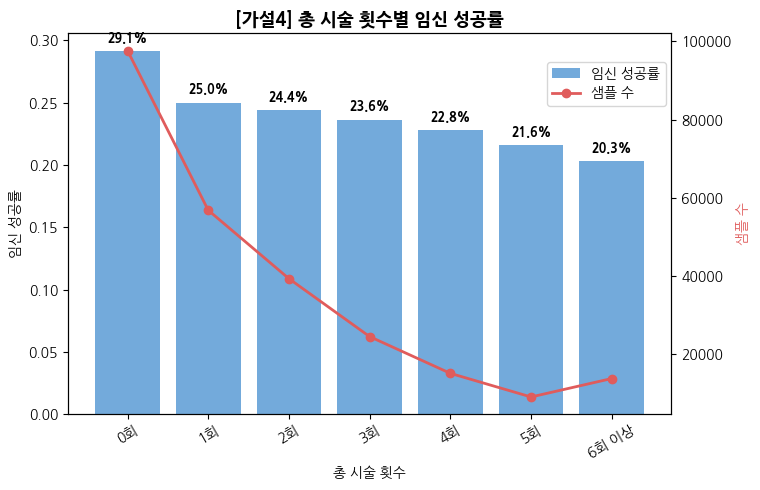

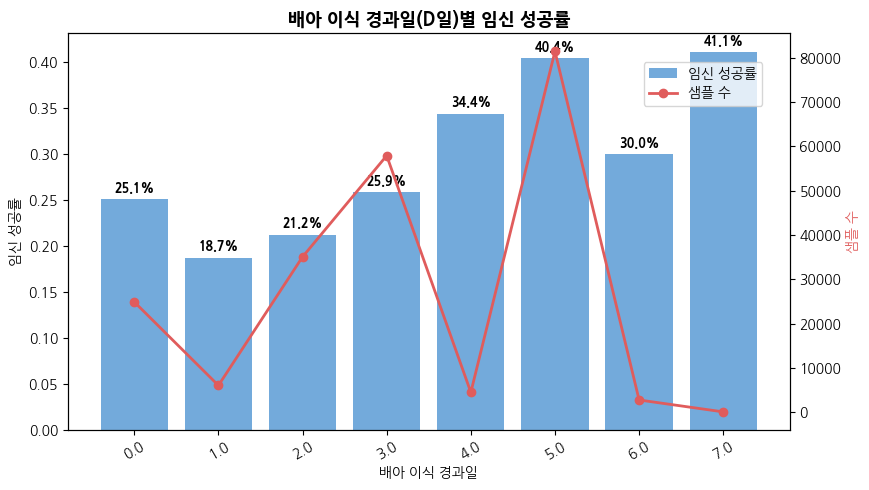

In [ ]:
def plot_cat_vs_target(df, col, target, title=None, order=None):
    if col not in df.columns:
        print(f"  컬럼 없음: {col}")
        return
    grp = df.groupby(col)[target].agg(success_rate="mean", count="count").reset_index()
    if order:
        grp[col] = pd.Categorical(grp[col], categories=order, ordered=True)
        grp = grp.sort_values(col)

    fig, ax1 = plt.subplots(figsize=(max(7, len(grp) * 1.1), 5))
    ax2 = ax1.twinx()
    bars = ax1.bar(grp[col].astype(str), grp["success_rate"], color="#5B9BD5", alpha=0.85, label="임신 성공률")
    ax2.plot(grp[col].astype(str), grp["count"], color="#E05C5C", marker="o", linewidth=2, label="샘플 수")
    for bar, row in zip(bars, grp.itertuples()):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005,
                 f"{row.success_rate:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax1.set_ylabel("임신 성공률"); ax2.set_ylabel("샘플 수", color="#E05C5C")
    ax1.set_xlabel(col); ax1.tick_params(axis="x", rotation=30)
    plt.title(title or f"{col}별 임신 성공률", fontsize=13, fontweight="bold")
    fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
    plt.tight_layout(); plt.show()


# 가설 1: 나이대별 성공률
plot_cat_vs_target(df, "시술 당시 나이", TARGET, "[가설1] 나이대별 임신 성공률", AGE_ORDER)

# 가설 2: 시술 유형별 성공률
plot_cat_vs_target(df, "시술 유형", TARGET, "[가설2] 시술 유형별 임신 성공률")

# 가설 3: 이식 배아 수별 성공률
plot_cat_vs_target(df, "이식된 배아 수", TARGET, "[가설3] 이식된 배아 수별 임신 성공률")

# 가설 4: 총 시술 횟수별 성공률
plot_cat_vs_target(df, "총 시술 횟수", TARGET, "[가설4] 총 시술 횟수별 임신 성공률", COUNT_ORDER)

# 배아 이식 경과일(D일)별 성공률
plot_cat_vs_target(df, "배아 이식 경과일", TARGET, "배아 이식 경과일(D일)별 임신 성공률")

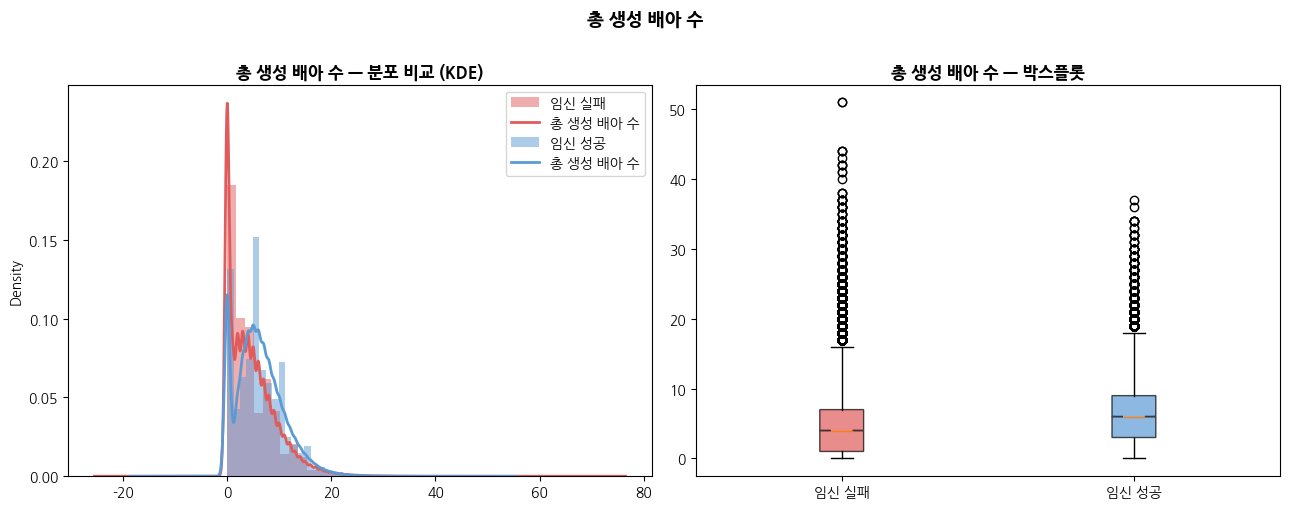

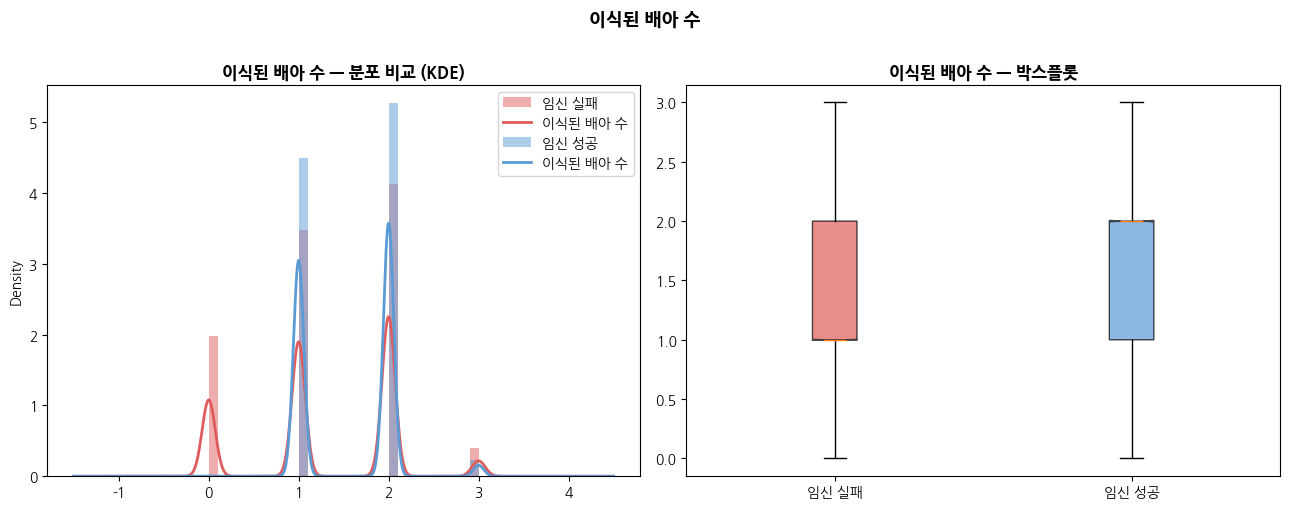

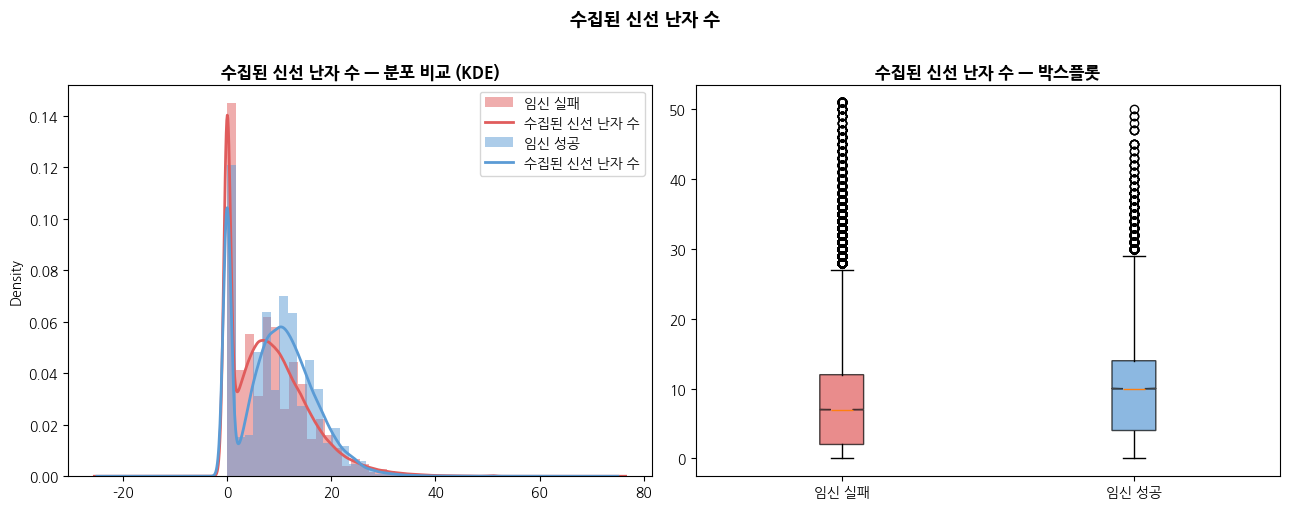

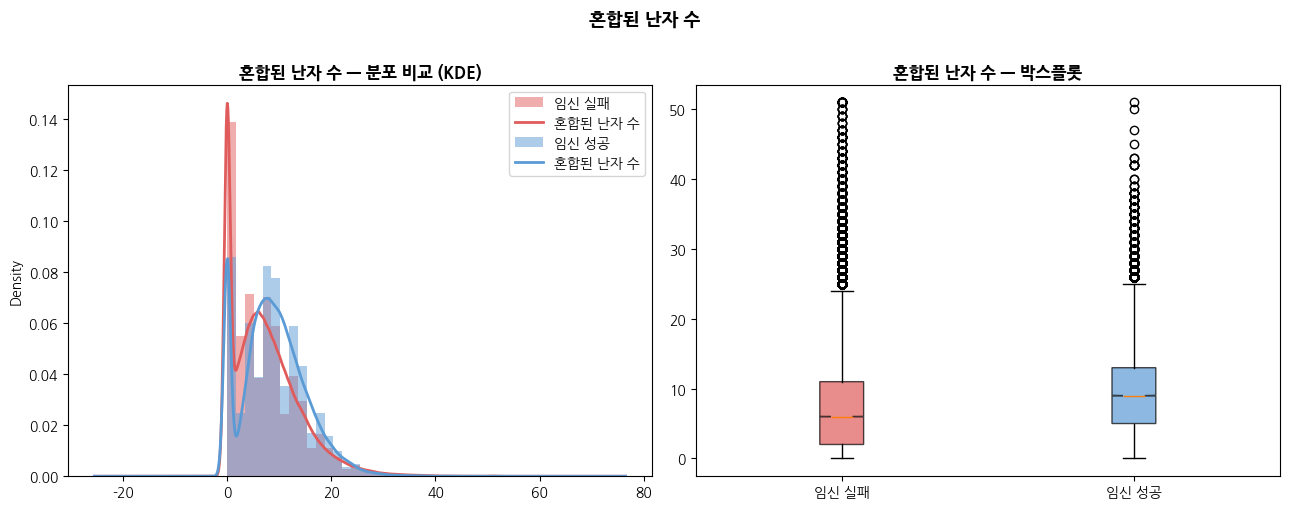

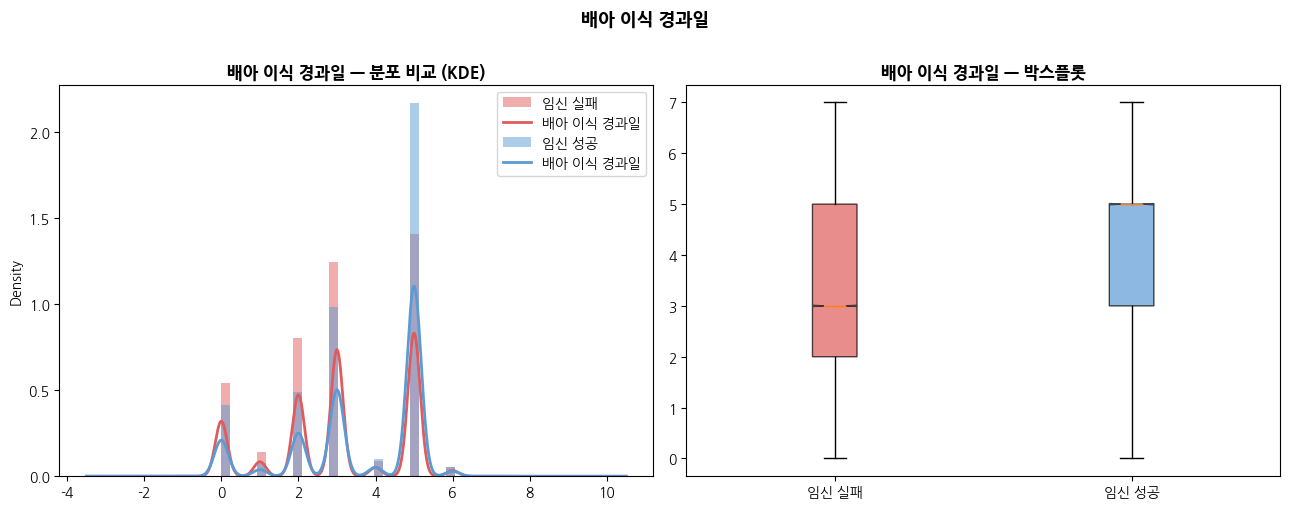

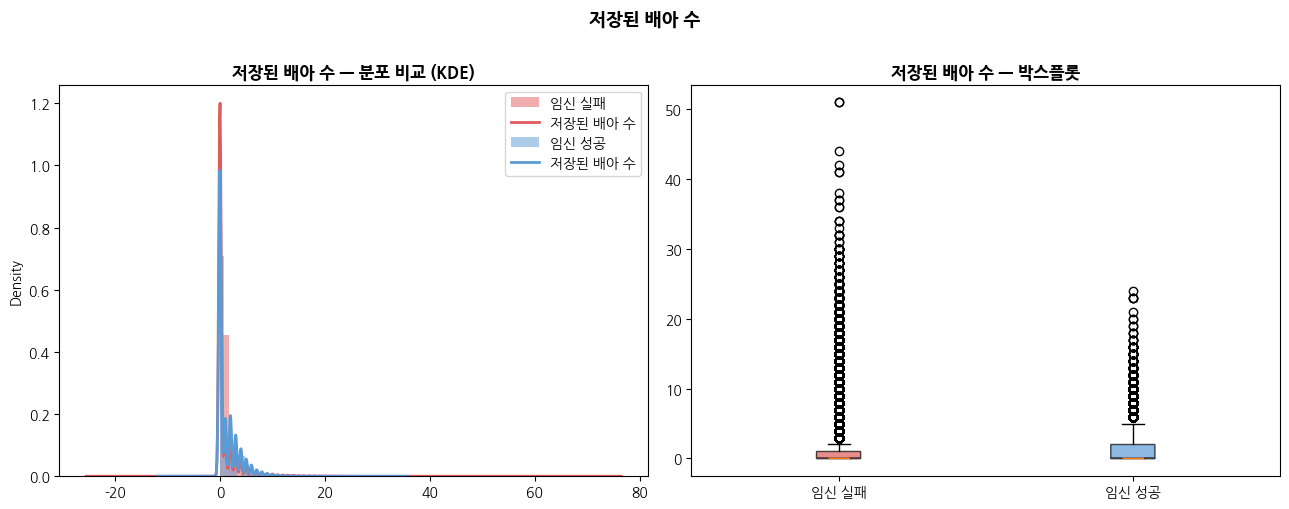

In [ ]:
def plot_num_vs_target(df, col, target, title=None):
    if col not in df.columns:
        return
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for val, label, color in [(0, "임신 실패", "#E05C5C"), (1, "임신 성공", "#5B9BD5")]:
        subset = df.loc[df[target] == val, col].dropna()
        axes[0].hist(subset, bins=30, alpha=0.5, color=color, label=label, density=True)
        subset.plot.kde(ax=axes[0], color=color, linewidth=2)
    axes[0].set_title(f"{col} — 분포 비교 (KDE)", fontweight="bold")
    axes[0].legend()

    bp_data = [df.loc[df[target] == 0, col].dropna(), df.loc[df[target] == 1, col].dropna()]
    bp = axes[1].boxplot(bp_data, labels=["임신 실패", "임신 성공"], patch_artist=True, notch=True)
    for patch, color in zip(bp["boxes"], ["#E05C5C", "#5B9BD5"]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[1].set_title(f"{col} — 박스플롯", fontweight="bold")
    plt.suptitle(title or col, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout(); plt.show()


for col in ["총 생성 배아 수", "이식된 배아 수", "수집된 신선 난자 수",
            "혼합된 난자 수", "배아 이식 경과일", "저장된 배아 수"]:
    plot_num_vs_target(df, col, TARGET)


5. 상관관계 분석


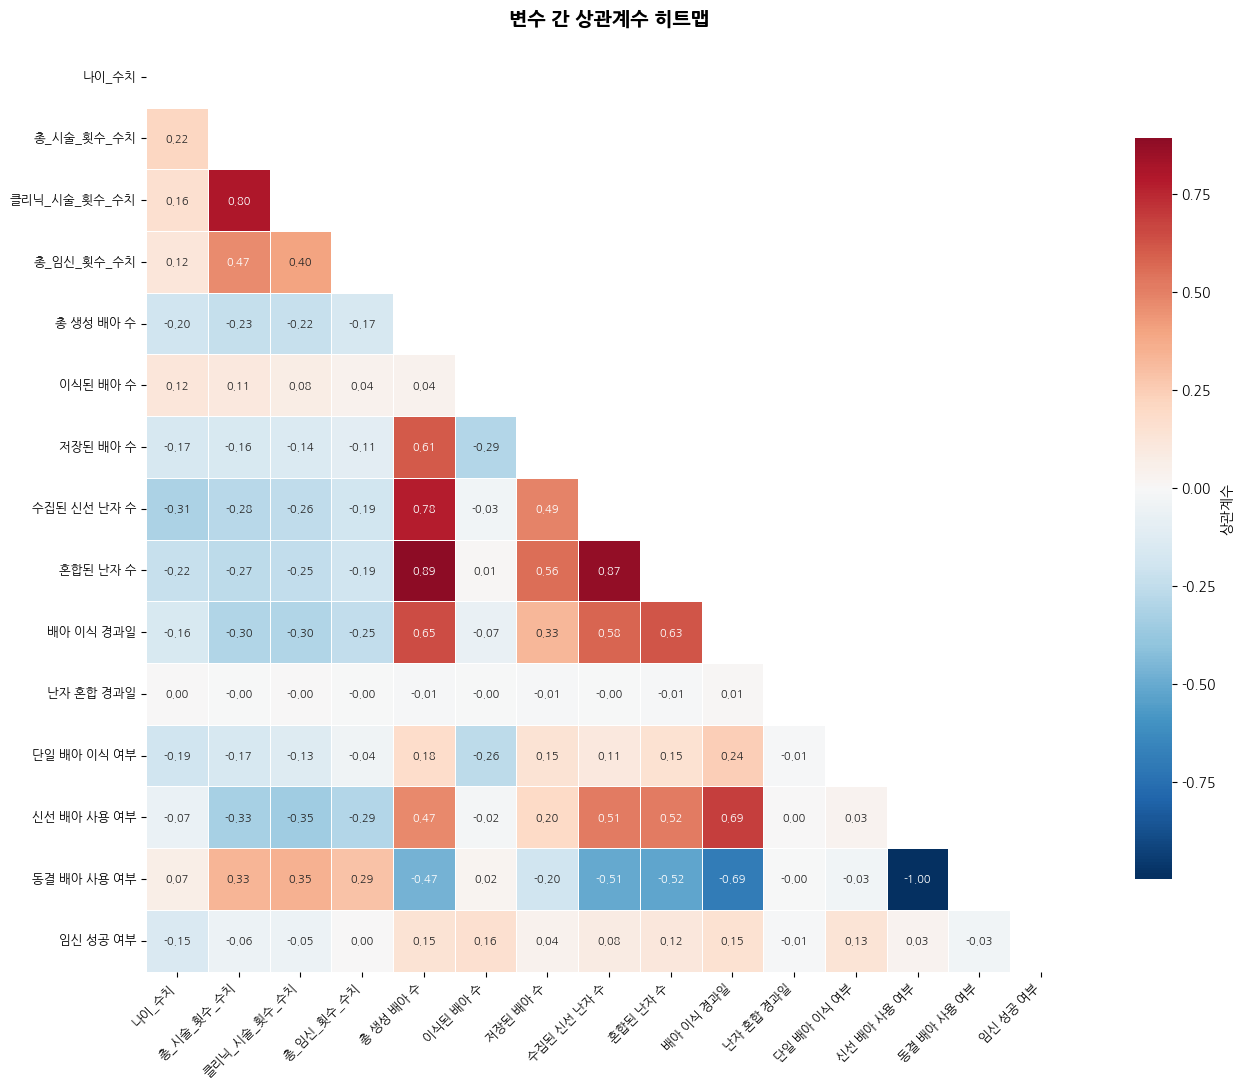

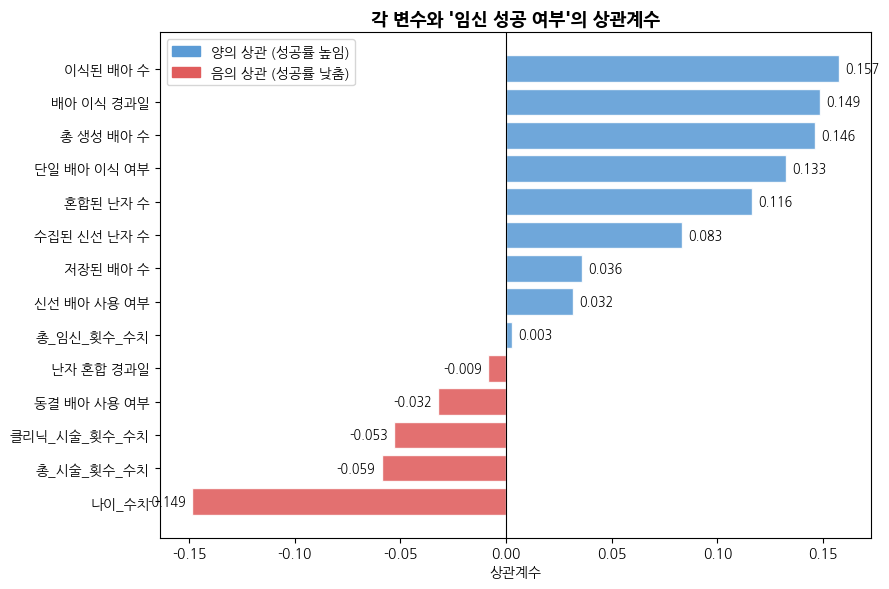


  타겟과 상관계수 TOP 10:
이식된 배아 수        0.1575
나이_수치           0.1487
배아 이식 경과일       0.1486
총 생성 배아 수       0.1461
단일 배아 이식 여부     0.1326
혼합된 난자 수        0.1161
수집된 신선 난자 수     0.0830
총_시술_횟수_수치      0.0589
클리닉_시술_횟수_수치    0.0528
저장된 배아 수        0.0360


In [16]:
print("\n" + "=" * 60)
print("5. 상관관계 분석")
print("=" * 60)

df_corr = df.copy()

# 범주형을 수치로 변환 (상관분석용)
df_corr["나이_수치"]             = df_corr["시술 당시 나이"].map(AGE_MAP)
df_corr["총_시술_횟수_수치"]     = df_corr["총 시술 횟수"].map(COUNT_MAP)
df_corr["클리닉_시술_횟수_수치"] = df_corr["클리닉 내 총 시술 횟수"].map(COUNT_MAP)
df_corr["총_임신_횟수_수치"]     = df_corr["총 임신 횟수"].map(COUNT_MAP)

CORR_COLS = [c for c in [
    "나이_수치", "총_시술_횟수_수치", "클리닉_시술_횟수_수치", "총_임신_횟수_수치",
    "총 생성 배아 수", "이식된 배아 수", "저장된 배아 수",
    "수집된 신선 난자 수", "혼합된 난자 수",
    "배아 이식 경과일", "난자 혼합 경과일",
    "단일 배아 이식 여부", "신선 배아 사용 여부", "동결 배아 사용 여부",
    TARGET,
] if c in df_corr.columns]

corr_matrix = df_corr[CORR_COLS].corr()

# Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(14, 11))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, square=True,
    linewidths=0.4, cbar_kws={"label": "상관계수", "shrink": 0.8},
    annot_kws={"size": 8},
)
plt.title("변수 간 상관계수 히트맵", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout(); plt.show()

# 타겟과의 상관계수 막대그래프
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values()
colors_corr = ["#E05C5C" if v < 0 else "#5B9BD5" for v in target_corr.values]
plt.figure(figsize=(9, max(6, len(target_corr) * 0.42)))
bars = plt.barh(target_corr.index, target_corr.values, color=colors_corr, alpha=0.88, edgecolor="white")
plt.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, target_corr.values):
    plt.text(val + (0.003 if val >= 0 else -0.003),
             bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center",
             ha="left" if val >= 0 else "right", fontsize=9)
plt.xlabel("상관계수")
plt.title(f"각 변수와 '{TARGET}'의 상관계수", fontsize=13, fontweight="bold")
legend_patches = [
    mpatches.Patch(color="#5B9BD5", label="양의 상관 (성공률 높임)"),
    mpatches.Patch(color="#E05C5C", label="음의 상관 (성공률 낮춤)"),
]
plt.legend(handles=legend_patches)
plt.tight_layout(); plt.show()

print("\n  타겟과 상관계수 TOP 10:")
print(target_corr.abs().sort_values(ascending=False).head(10).round(4).to_string())

피처 엔지니어링

In [17]:
def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 불임 원인 개수 합산
    cause_cols = [c for c in df.columns if "불임 원인 -" in c]
    df["불임_원인_합계"] = df[cause_cols].sum(axis=1)

    # 주요 불임 원인 합계
    primary_cols = [c for c in ["남성 주 불임 원인", "여성 주 불임 원인", "부부 주 불임 원인"]
                    if c in df.columns]
    df["주요_불임_원인_합계"] = df[primary_cols].sum(axis=1)

    # 이식 효율: 이식 배아 / 생성 배아
    df["이식_효율"] = np.where(
        df["총 생성 배아 수"] > 0,
        df["이식된 배아 수"] / df["총 생성 배아 수"], 0
    )

    # ICSI 비율
    if "미세주입에서 생성된 배아 수" in df.columns:
        df["ICSI_비율"] = np.where(
            df["총 생성 배아 수"] > 0,
            df["미세주입에서 생성된 배아 수"] / df["총 생성 배아 수"], 0
        )

    # 과거 임신 성공률
    if "총 임신 횟수" in df.columns and "총 시술 횟수" in df.columns:
        df["과거_임신_성공률"] = np.where(
            df["총 시술 횟수"] > 0,
            df["총 임신 횟수"] / (df["총 시술 횟수"] + 1), 0
        )

    # 배아 전략 플래그 (동결=1, 기증=2, 신선=0)
    for col in ["동결 배아 사용 여부", "신선 배아 사용 여부", "기증 배아 사용 여부"]:
        if col not in df.columns:
            df[col] = 0
    df["배아_전략"] = (
        df["동결 배아 사용 여부"] * 1
        + df["신선 배아 사용 여부"] * 0
        + df["기증 배아 사용 여부"] * 2
    )

    # 저장 비율
    df["저장_비율"] = np.where(
        df["총 생성 배아 수"] > 0,
        df["저장된 배아 수"] / df["총 생성 배아 수"], 0
    )

    # 기증 사용 플래그
    df["기증_사용"] = (
        (df.get("난자 출처", pd.Series(0, index=df.index)) == 1)
        | (df.get("정자 출처", pd.Series(0, index=df.index)) == 1)
    ).astype(int)

      # 동결배아 활용률: 실제 해동 사용 / 저장 총수
    #   → 높을수록 보관 배아를 적극 활용한 주기
    if "해동된 배아 수" in df.columns:
        df["동결배아_활용률"] = np.where(
            df["저장된 배아 수"] > 0,
            df["해동된 배아 수"] / df["저장된 배아 수"], 0
        )

    # ICSI 후 동결된 배아 비율: ICSI 저장 / 이식 배아
    #   → 미세주입 배아 중 실제 이식 외 저장된 비중
    if "미세주입 후 저장된 배아 수" in df.columns:
        df["ICSI동결_이식비율"] = np.where(
            df["이식된 배아 수"] > 0,
            df["미세주입 후 저장된 배아 수"] / df["이식된 배아 수"], 0
        )

    # 순수 동결 주기 플래그: 동결=1 & 신선=0
    #   → 신선 배아 없이 동결만 사용한 주기 (FER 주기)
    df["순수동결_주기"] = (
        (df["동결 배아 사용 여부"] == 1) & (df["신선 배아 사용 여부"] == 0)
    ).astype(int)

    # 동결 잉여율: (저장 - 해동) / 저장
    #   → 아직 남아있는 동결 배아 비율 (낮을수록 소진됨)
    if "해동된 배아 수" in df.columns:
        remaining = (df["저장된 배아 수"] - df["해동된 배아 수"]).clip(lower=0)
        df["동결배아_잉여율"] = np.where(
            df["저장된 배아 수"] > 0,
            remaining / df["저장된 배아 수"], 0
        )

    # 동결 배아 총량 지수: 저장 + 해동 (해동 포함 시)
    #   → 누적 동결 배아 규모를 반영
    if "해동된 배아 수" in df.columns:
        df["동결배아_총량"] = df["저장된 배아 수"] + df["해동된 배아 수"]
    # 전처리 후 "시술 당시 나이"는 순서형 정수 0~5 (-1=알 수 없음)
    # "수집된 신선 난자 수"는 연속형 수치

    if "수집된 신선 난자 수" in df.columns and "시술 당시 나이" in df.columns:
        age_num = df["시술 당시 나이"].replace(-1, np.nan)  # 알 수 없음 → NaN
        egg_cnt = df["수집된 신선 난자 수"]

        # 나이 × 난자 수 교호작용항
        #   → 나이 코드가 높고 난자도 많은 경우 큰 값 (고령 고수확)
        df["나이x난자수"] = (age_num * egg_cnt).fillna(0)

        # 나이 보정 난자 효율: 난자 수 / (나이 코드 + 1)
        #   → 같은 난자 수라도 나이가 낮을수록 효율이 높음을 표현
        df["나이보정_난자효율"] = (egg_cnt / (age_num.fillna(0) + 1))

        # 혼합 난자 대비 수정 효율: 총 배아 / 혼합 난자
        #   → 난자 수정 성공률 근사
        if "혼합된 난자 수" in df.columns:
            df["수정_효율"] = np.where(
                df["혼합된 난자 수"] > 0,
                df["총 생성 배아 수"] / df["혼합된 난자 수"], 0
            )

        # 고령 저반응 플래그: 나이 >= 3 (만40-42세+) AND 난자 수 < 중앙값
        #   → 고령임에도 채취 수가 낮은 불량 예후 케이스
        egg_median = egg_cnt.median()
        df["고령저반응"] = (
            (age_num >= 3) & (egg_cnt < egg_median)
        ).fillna(False).astype(int)

        # 젊고 고수확 플래그: 나이 <= 1 (만18-37세) AND 난자 수 >= 75th 백분위
        egg_q75 = egg_cnt.quantile(0.75)
        df["젊고고수확"] = (
            (age_num <= 1) & (egg_cnt >= egg_q75)
        ).fillna(False).astype(int)
      # 배아 손실 수: 생성 - 이식 - 저장 (폐기된 배아 추정)
    #   → 낮을수록 배아 관리 효율이 좋음
    df["배아_손실수"] = (
        df["총 생성 배아 수"]
        - df["이식된 배아 수"]
        - df["저장된 배아 수"]
    ).clip(lower=0)

    # 배아 총 활용률: (이식 + 저장) / 생성
    #   → 1에 가까울수록 생성 배아를 모두 활용
    df["배아_총활용률"] = np.where(
        df["총 생성 배아 수"] > 0,
        (df["이식된 배아 수"] + df["저장된 배아 수"]) / df["총 생성 배아 수"], 0
    ).clip(0, 1)

    # 배아 풍요도 구간: 0=없음, 1=적음(1-3), 2=보통(4-7), 3=많음(8+)
    embryo_max = max(df["총 생성 배아 수"].max() + 1, 9)
    df["배아_풍요도"] = pd.cut(
        df["총 생성 배아 수"],
        bins=[-1, 0, 3, 7, embryo_max],
        labels=[0, 1, 2, 3]
    ).astype(float).fillna(0).astype(int)

    # 다배아 이식 플래그: 이식 배아 >= 3 (다태 임신 위험 기준)
    df["다배아이식_플래그"] = (df["이식된 배아 수"] >= 3).astype(int)

    # 배아 품질 복합 지수: 이식 효율 × 배아 총 활용률
    #   → 두 효율 지표를 동시에 고려한 종합 배아 품질 점수 (0~1)
    df["배아품질_복합지수"] = df["이식_효율"] * df["배아_총활용률"]

    # ICSI 배아 우위 비율: ICSI 배아 / 총 배아
    #   → 미세주입 의존도. 높을수록 정자 문제 가능성
    if "미세주입에서 생성된 배아 수" in df.columns:
        df["ICSI배아_우위비율"] = np.where(
            df["총 생성 배아 수"] > 0,
            df["미세주입에서 생성된 배아 수"] / df["총 생성 배아 수"], 0
        )

    # 이식 집중도: 이식 배아 / (이식 + 저장)
    #   → 보관보다 즉시 이식에 집중한 정도
    denom_43 = df["이식된 배아 수"] + df["저장된 배아 수"]
    df["이식_집중도"] = np.where(denom_43 > 0, df["이식된 배아 수"] / denom_43, 0)

    if "시술 유형" in df.columns and "시술 당시 나이" in df.columns:
        age_num2 = df["시술 당시 나이"].replace(-1, 0)  # 알 수 없음 → 0

        # 나이 × 시술 유형 교호작용항
        #   → IVF 시술 + 나이가 높을수록 큰 값. IVF의 나이 의존성 포착
        df["나이x시술유형"] = age_num2 * df["시술 유형"]

        # 고령 IVF 플래그: 나이 >= 3 (만40+) AND IVF 시술
        #   → 고령에서 IVF를 선택한 고위험 케이스
        df["고령IVF"] = (
            (df["시술 당시 나이"] >= 3) & (df["시술 유형"] == 1)
        ).astype(int)

        # 젊은 DI 플래그: 나이 <= 1 (만18-37세) AND DI 시술
        #   → 상대적으로 단순 시술로도 기대치가 높은 케이스
        df["젊은DI"] = (
            (df["시술 당시 나이"] <= 1) & (df["시술 유형"] == 0)
        ).astype(int)

        # 나이 구간별 시술 유형 복합 코드: age_band * 10 + procedure_type
        #   → 나이-시술 조합을 단일 범주로 표현 (트리 모델에서 분기 포착)
        df["나이_시술_복합코드"] = df["시술 당시 나이"].clip(lower=0) * 10 + df["시술 유형"]

    if "총 시술 횟수" in df.columns and "시술 당시 나이" in df.columns:
        age_num3  = df["시술 당시 나이"].replace(-1, 0)
        trial_num = df["총 시술 횟수"].replace(-1, 0)

        # 나이 × 총 시술 횟수 교호작용항
        #   → 나이가 많고 시술 횟수가 많을수록 큰 값 (반복 실패 + 고령)
        df["나이x총시술횟수"] = age_num3 * trial_num

        # 클리닉 내 시술 횟수 교호작용 (동일 클리닉 내 축적 경험)
        if "클리닉 내 총 시술 횟수" in df.columns:
            clinic_num = df["클리닉 내 총 시술 횟수"].replace(-1, 0)
            df["나이x클리닉시술횟수"] = age_num3 * clinic_num

        # IVF 전용 시술 횟수 × 나이
        if "IVF 시술 횟수" in df.columns:
            ivf_num = df["IVF 시술 횟수"].replace(-1, 0)
            df["나이xIVF횟수"] = age_num3 * ivf_num

        # 고령 반복 시술 플래그: 나이 >= 3 AND 총 시술 횟수 >= 3
        #   → 고령 + 반복 실패 이력의 복합 고위험군
        df["고령반복시술"] = (
            (df["시술 당시 나이"] >= 3) & (trial_num >= 3)
        ).astype(int)

        # 시술 누적 부담 지수: 나이 × (총 시술 + IVF 시술) / 2
        #   → 나이와 시술 이력을 결합한 누적 부담 점수
        if "IVF 시술 횟수" in df.columns:
            ivf_num = df["IVF 시술 횟수"].replace(-1, 0)
            df["시술부담_지수"] = age_num3 * (trial_num + ivf_num) / 2

    print(f"  피처 수: {df.shape[1]}개")
    return df

X_train = feature_engineering(X_pp)
X_test  = feature_engineering(X_test_pp)

  피처 수: 110개
  피처 수: 110개


In [18]:
common_cols = [c for c in X_train.columns if c in X_test.columns]
X_train = X_train[common_cols]
X_test  = X_test[common_cols]

print(f"  최종 Train 피처: {X_train.shape[1]}개")
print(f"  최종 Test  피처: {X_test.shape[1]}개")

  최종 Train 피처: 110개
  최종 Test  피처: 110개


모델 학습

In [19]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_lgb  = np.zeros(len(X_train))
oof_xgb  = np.zeros(len(X_train))
oof_cat  = np.zeros(len(X_train))
pred_lgb = np.zeros(len(X_test))
pred_xgb = np.zeros(len(X_test))
pred_cat = np.zeros(len(X_test))

In [20]:
# ============================================================
# 7. XGBoost 단독 모델 학습 (5-Fold Stratified CV)
# ============================================================
print("\n" + "=" * 60)
print("7. XGBoost 단독 모델 학습 (5-Fold Stratified CV)")
print("=" * 60)

N_SPLITS = 5
SEED     = 42
skf      = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_pred  = np.zeros(len(X_train))
test_pred = np.zeros(len(X_test))
fold_aucs = []
models    = []

xgb_params = {
    "objective":        "binary:logistic",
    "eval_metric":      "auc",
    "learning_rate":    0.05,
    "max_depth":        6,
    "min_child_weight": 5,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "gamma":            0.1,
    "reg_alpha":        0.1,
    "reg_lambda":       1.0,
    "seed":             SEED,
    "n_jobs":           -1,
    "tree_method":      "hist",
    "verbosity":        0,
}

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx],       y.iloc[val_idx]

    dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=list(X_train.columns))
    dval   = xgb.DMatrix(X_val, label=y_val, feature_names=list(X_train.columns))

    model = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round=2000,
        evals=[(dval, "val")],
        early_stopping_rounds=100,
        verbose_eval=500,
    )

    oof_pred[val_idx]  = model.predict(dval)
    test_pred         += model.predict(
        xgb.DMatrix(X_test, feature_names=list(X_train.columns))
    ) / N_SPLITS
    fold_auc           = roc_auc_score(y_val, oof_pred[val_idx])
    fold_aucs.append(fold_auc)
    models.append(model)

    print(f"  Fold {fold+1}  |  best iter: {model.best_iteration:>4}  |  AUC: {fold_auc:.4f}")

oof_auc = roc_auc_score(y, oof_pred)
print(f"\n  ── 폴드별 AUC: {[round(a, 4) for a in fold_aucs]}")
print(f"  ── AUC 평균 ± 표준편차: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"  ★ OOF AUC (전체): {oof_auc:.4f}")

oof_xgb  = oof_pred.copy()
pred_xgb = test_pred.copy()



7. XGBoost 단독 모델 학습 (5-Fold Stratified CV)
[0]	val-auc:0.72416
[246]	val-auc:0.73692
  Fold 1  |  best iter:  146  |  AUC: 0.7369
[0]	val-auc:0.72690
[354]	val-auc:0.74241
  Fold 2  |  best iter:  254  |  AUC: 0.7424
[0]	val-auc:0.72649
[275]	val-auc:0.73949
  Fold 3  |  best iter:  175  |  AUC: 0.7395
[0]	val-auc:0.72514
[267]	val-auc:0.73697
  Fold 4  |  best iter:  167  |  AUC: 0.7370
[0]	val-auc:0.72564
[324]	val-auc:0.74006
  Fold 5  |  best iter:  224  |  AUC: 0.7401

  ── 폴드별 AUC: [np.float64(0.7369), np.float64(0.7424), np.float64(0.7395), np.float64(0.737), np.float64(0.7401)]
  ── AUC 평균 ± 표준편차: 0.7392 ± 0.0021
  ★ OOF AUC (전체): 0.7392


In [21]:
# ============================================================
# 7. CatBoost 단독 모델 학습 (5-Fold Stratified CV)
# ============================================================
print("\n" + "=" * 60)
print("7. CatBoost 단독 모델 학습 (5-Fold Stratified CV)")
print("=" * 60)

N_SPLITS = 5
SEED     = 42
skf      = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_pred  = np.zeros(len(X_train))
test_pred = np.zeros(len(X_test))
fold_aucs = []
models    = []

cat_params = {
    "iterations":          2000,
    "learning_rate":       0.05,
    "depth":               6,
    "l2_leaf_reg":         3,
    "eval_metric":         "AUC",
    "early_stopping_rounds": 100,
    "random_seed":         SEED,
    "verbose":             500,
    "task_type":           "CPU",
    "bootstrap_type":      "Bernoulli",
    "subsample":           0.8,
    "colsample_bylevel":   0.8,
}

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx],       y.iloc[val_idx]

    model = CatBoostClassifier(**cat_params)
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        use_best_model=True,
    )

    oof_pred[val_idx]  = model.predict_proba(X_val)[:, 1]
    test_pred         += model.predict_proba(X_test)[:, 1] / N_SPLITS
    fold_auc           = roc_auc_score(y_val, oof_pred[val_idx])
    fold_aucs.append(fold_auc)
    models.append(model)

    print(f"  Fold {fold+1}  |  best iter: {model.best_iteration_:>4}  |  AUC: {fold_auc:.4f}")

oof_auc = roc_auc_score(y, oof_pred)
print(f"\n  ── 폴드별 AUC: {[round(a, 4) for a in fold_aucs]}")
print(f"  ── AUC 평균 ± 표준편차: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"  ★ OOF AUC (전체): {oof_auc:.4f}")


oof_cat  = oof_pred.copy()
pred_cat = test_pred.copy()


7. CatBoost 단독 모델 학습 (5-Fold Stratified CV)
0:	test: 0.7078795	best: 0.7078795 (0)	total: 140ms	remaining: 4m 40s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7376192552
bestIteration = 325

Shrink model to first 326 iterations.
  Fold 1  |  best iter:  325  |  AUC: 0.7376
0:	test: 0.7184765	best: 0.7184765 (0)	total: 95.2ms	remaining: 3m 10s
500:	test: 0.7430008	best: 0.7430429 (476)	total: 49.9s	remaining: 2m 29s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7430530172
bestIteration = 614

Shrink model to first 615 iterations.
  Fold 2  |  best iter:  614  |  AUC: 0.7431
0:	test: 0.7160275	best: 0.7160275 (0)	total: 229ms	remaining: 7m 37s
500:	test: 0.7393962	best: 0.7394214 (476)	total: 1m 25s	remaining: 4m 14s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7394213618
bestIteration = 476

Shrink model to first 477 iterations.
  Fold 3  |  best iter:  476  |  AUC: 0.7394
0:	test: 0.7088054	best: 0.7088054 (0)	tota

앙상블1

In [44]:
# ============================================================
# 8. 앙상블 — XGBoost + CatBoost (2-Model Ensemble)
# ============================================================

print("\n" + "=" * 60)
print("9. XGBoost + CatBoost 앙상블")
print("=" * 60)

# ── 단독 모델 OOF AUC 출력 ──────────────────────────────────
auc_xgb = roc_auc_score(y, oof_xgb)
auc_cat = roc_auc_score(y, oof_cat)
print(f"\n  XGBoost  OOF AUC : {auc_xgb:.4f}")
print(f"  CatBoost OOF AUC : {auc_cat:.4f}")

# OOF / 테스트 예측값 스택
oof_stack_2  = np.column_stack([oof_xgb,  oof_cat])   # (n_train, 2)
test_stack_2 = np.column_stack([pred_xgb, pred_cat])  # (n_test,  2)


9. XGBoost + CatBoost 앙상블

  XGBoost  OOF AUC : 0.7397
  CatBoost OOF AUC : 0.7397


In [45]:
# ──────────────────────────────────────────────────────────
# 방법 A : 단순 평균(두 모델을 동등하게 1/2씩 평균)
# ──────────────────────────────────────────────────────────
print("\n  ── 방법 A : Simple Average ──")
avg_oof_2  = oof_stack_2.mean(axis=1)
avg_pred_2 = test_stack_2.mean(axis=1)
print(f"  OOF AUC : {roc_auc_score(y, avg_oof_2):.4f}")


  ── 방법 A : Simple Average ──
  OOF AUC : 0.7399


In [46]:
# ──────────────────────────────────────────────────────────
# 방법 B : AUC 가중 평균(OOF AUC가 높은 모델에 더 많은 비중 부여)
# ──────────────────────────────────────────────────────────
print("\n  ── 방법 B : AUC-Weighted Average ──")
aucs_2   = np.array([auc_xgb, auc_cat])
weights_2 = aucs_2 / aucs_2.sum()
print(f"  가중치 → XGB: {weights_2[0]:.4f} | CAT: {weights_2[1]:.4f}")

wavg_oof_2  = (oof_stack_2  * weights_2).sum(axis=1)
wavg_pred_2 = (test_stack_2 * weights_2).sum(axis=1)
print(f"  OOF AUC : {roc_auc_score(y, wavg_oof_2):.4f}")


  ── 방법 B : AUC-Weighted Average ──
  가중치 → XGB: 0.5000 | CAT: 0.5000
  OOF AUC : 0.7399


In [47]:
# ──────────────────────────────────────────────────────────
# 방법 C : Stacking (메타 모델 = Logistic Regression)
# ──────────────────────────────────────────────────────────
# 두 모델의 OOF 예측값을 메타 피처로 사용해 LR을 학습
# → 어떤 상황에서 XGB vs CAT 중 누구를 더 믿을지 자동 학습
# 주의: OOF 예측값이 이미 누수 없이 생성되었으므로
#       전체 train으로 메타 모델 학습해도 안전
print("\n  ── 방법 C : Stacking (Meta = Logistic Regression) ──")

scaler_2   = StandardScaler()
meta_tr_2  = scaler_2.fit_transform(oof_stack_2)   # train OOF로만 fit
meta_te_2  = scaler_2.transform(test_stack_2)      # test는 transform만

meta_model_2 = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
meta_model_2.fit(meta_tr_2, y)

stack_oof_2  = meta_model_2.predict_proba(meta_tr_2)[:, 1]
stack_pred_2 = meta_model_2.predict_proba(meta_te_2)[:, 1]
stack_auc_2  = roc_auc_score(y, stack_oof_2)

print(f"  메타 계수 → XGB: {meta_model_2.coef_[0][0]:.4f} | "
      f"CAT: {meta_model_2.coef_[0][1]:.4f}")
print(f"  OOF AUC : {stack_auc_2:.4f}")


  ── 방법 C : Stacking (Meta = Logistic Regression) ──
  메타 계수 → XGB: 0.4949 | CAT: 0.4950
  OOF AUC : 0.7399


In [48]:
# ──────────────────────────────────────────────────────────
# 방법 D : Rank Average (leakage-free 버전)
# ──────────────────────────────────────────────────────────
# ⚠️ 주의: train OOF와 test 예측을 함께 rank 변환하면
#          test의 분포 정보가 rank 기준에 영향을 줍니다.
#          → train OOF와 test를 각각 독립적으로 rank 변환해야 합니다.
print("\n  ── 방법 D : Rank Average (leakage-free) ──")

def rank_normalize(arr):
    """각 열을 독립적으로 순위 변환 후 [0,1] 정규화"""
    ranked = np.apply_along_axis(
        lambda x: x.argsort().argsort() / (len(x) - 1), 0, arr
    )
    return ranked.mean(axis=1)

# train OOF와 test 각각 독립 rank 변환 (서로 섞지 않음)
rank_oof_2  = rank_normalize(oof_stack_2)   # train OOF만으로 rank
rank_pred_2 = rank_normalize(test_stack_2)  # test만으로 rank
rank_auc_2  = roc_auc_score(y, rank_oof_2)
print(f"  OOF AUC : {rank_auc_2:.4f}")


  ── 방법 D : Rank Average (leakage-free) ──
  OOF AUC : 0.7399


결과 비교 및 최종 제출

In [ ]:
# ──────────────────────────────────────────────────────────
# 결과 비교 및 최종 제출
# ──────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  XGBoost + CatBoost 앙상블 방법별 OOF AUC 비교")
print("=" * 60)

results_2 = {
    "단독 XGBoost"       : auc_xgb,
    "단독 CatBoost"      : auc_cat,
    "A. Simple Average"  : roc_auc_score(y, avg_oof_2),
    "B. Weighted Average": roc_auc_score(y, wavg_oof_2),
    "C. Stacking (LR)"   : stack_auc_2,
    "D. Rank Average"    : rank_auc_2,
}

best_method_2 = max(results_2, key=results_2.get)
for method, auc in sorted(results_2.items(), key=lambda x: x[1], reverse=True):
    marker = " ★ BEST" if method == best_method_2 else ""
    print(f"  {method:<24} AUC: {auc:.4f}{marker}")

# 최종 예측값 선택
best_preds_2 = {
    "단독 XGBoost"       : pred_xgb,
    "단독 CatBoost"      : pred_cat,
    "A. Simple Average"  : avg_pred_2,
    "B. Weighted Average": wavg_pred_2,
    "C. Stacking (LR)"   : stack_pred_2,
    "D. Rank Average"    : rank_pred_2,
}

final_pred_2 = best_preds_2[best_method_2]
print(f"\n  최종 선택 방법: {best_method_2}")

submission_2 = pd.DataFrame({
    "ID"         : test[ID_COL],
    "probability": final_pred_2,
})
submission_2.to_csv("submission_xgb_cat_ensemble.csv", index=False)
print(f"  submission_xgb_cat_ensemble.csv 저장 완료")
print(f"  예측 확률 범위 : [{final_pred_2.min():.4f}, {final_pred_2.max():.4f}]")
print(f"  예측 확률 평균 : {final_pred_2.mean():.4f}")


  XGBoost + CatBoost 앙상블 방법별 OOF AUC 비교
  C. Stacking (LR)         AUC: 0.7399 ★ BEST
  D. Rank Average          AUC: 0.7399
  B. Weighted Average      AUC: 0.7399
  A. Simple Average        AUC: 0.7399
  단독 CatBoost              AUC: 0.7397
  단독 XGBoost               AUC: 0.7392

  최종 선택 방법: C. Stacking (LR)
  submission_xgb_cat_ensemble.csv 저장 완료
  예측 확률 범위 : [0.0534, 0.8644]
  예측 확률 평균 : 0.2583


optuna

In [31]:
# ============================================================

!pip install optuna -q

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)  # 불필요한 로그 제거

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 18.7 MB/s eta 0:00:00


In [33]:
# ============================================================
# 10-1. XGBoost Optuna 튜닝
# ============================================================
print("\n" + "=" * 60)
print("10-1. XGBoost Optuna 튜닝 (50 trials)")
print("=" * 60)

def objective_xgb(trial):
    params = {
        "objective":        "binary:logistic",
        "eval_metric":      "auc",
        "tree_method":      "hist",
        "seed":             SEED,
        "n_jobs":           -1,
        "verbosity":        0,
        # ── Optuna 탐색 공간 ──────────────────────────────
        "learning_rate":    trial.suggest_float("learning_rate",    0.01, 0.3,  log=True),
        "max_depth":        trial.suggest_int(  "max_depth",        3,    9),
        "min_child_weight": trial.suggest_int(  "min_child_weight", 1,    20),
        "subsample":        trial.suggest_float("subsample",        0.5,  1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5,  1.0),
        "gamma":            trial.suggest_float("gamma",            0.0,  5.0),
        "reg_alpha":        trial.suggest_float("reg_alpha",        1e-8, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda",       1e-8, 10.0, log=True),
    }

    # 3-Fold CV로 빠르게 평가 (튜닝 속도 확보)
    cv_skf  = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    auc_scores = []

    for tr_idx, val_idx in cv_skf.split(X_train, y):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx],       y.iloc[val_idx]

        dtrain = xgb.DMatrix(X_tr,  label=y_tr,  feature_names=list(X_train.columns))
        dval   = xgb.DMatrix(X_val, label=y_val, feature_names=list(X_train.columns))

        model = xgb.train(
            params, dtrain,
            num_boost_round=1000,
            evals=[(dval, "val")],
            early_stopping_rounds=50,
            verbose_eval=False,
        )
        pred = model.predict(dval)
        auc_scores.append(roc_auc_score(y_val, pred))

    return np.mean(auc_scores)


study_xgb = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=SEED),
    study_name="xgb_tuning",
)
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

best_xgb_params = study_xgb.best_params
best_xgb_params.update({
    "objective":   "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "seed":        SEED,
    "n_jobs":      -1,
    "verbosity":   0,
})

print(f"\n  XGBoost 최적 파라미터:")
for k, v in study_xgb.best_params.items():
    print(f"    {k:<22}: {v}")
print(f"  Best CV AUC (3-fold): {study_xgb.best_value:.4f}")


# ── 최적 파라미터로 5-Fold 재학습 ────────────────────────────
print("\n  최적 파라미터로 5-Fold 재학습 중...")
skf_final = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_xgb   = np.zeros(len(X_train))
pred_xgb  = np.zeros(len(X_test))
fold_aucs_xgb = []

for fold, (tr_idx, val_idx) in enumerate(skf_final.split(X_train, y)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx],       y.iloc[val_idx]

    dtrain = xgb.DMatrix(X_tr,  label=y_tr,  feature_names=list(X_train.columns))
    dval   = xgb.DMatrix(X_val, label=y_val, feature_names=list(X_train.columns))

    model = xgb.train(
        best_xgb_params, dtrain,
        num_boost_round=2000,
        evals=[(dval, "val")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )
    oof_xgb[val_idx] = model.predict(dval)
    pred_xgb        += model.predict(
        xgb.DMatrix(X_test, feature_names=list(X_train.columns))
    ) / N_SPLITS
    fold_aucs_xgb.append(roc_auc_score(y_val, oof_xgb[val_idx]))
    print(f"    Fold {fold+1}  AUC: {fold_aucs_xgb[-1]:.4f}")

xgb_oof_auc = roc_auc_score(y, oof_xgb)
print(f"\n  XGBoost OOF AUC (튜닝 전): 0.7392")
print(f"  XGBoost OOF AUC (튜닝 후): {xgb_oof_auc:.4f}")



10-1. XGBoost Optuna 튜닝 (50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]


  XGBoost 최적 파라미터:
    learning_rate         : 0.022420091477793697
    max_depth             : 5
    min_child_weight      : 8
    subsample             : 0.6342172224353327
    colsample_bytree      : 0.7036131908617933
    gamma                 : 1.7694743128595933
    reg_alpha             : 3.966860264449361
    reg_lambda            : 3.8738199704546805e-05
  Best CV AUC (3-fold): 0.7395

  최적 파라미터로 5-Fold 재학습 중...
    Fold 1  AUC: 0.7375
    Fold 2  AUC: 0.7427
    Fold 3  AUC: 0.7400
    Fold 4  AUC: 0.7379
    Fold 5  AUC: 0.7404

  XGBoost OOF AUC (튜닝 전): 0.7392
  XGBoost OOF AUC (튜닝 후): 0.7397


In [34]:
# ============================================================
# 10-2. CatBoost Optuna 튜닝
# ============================================================
print("\n" + "=" * 60)
print("10-2. CatBoost Optuna 튜닝 (50 trials)")
print("=" * 60)

def objective_cat(trial):
    params = {
        "eval_metric":          "AUC",
        "early_stopping_rounds": 50,
        "random_seed":          SEED,
        "verbose":              0,
        "task_type":            "CPU",
        # ── Optuna 탐색 공간 ──────────────────────────────
        "iterations":           trial.suggest_int(  "iterations",     300,  1500),
        "learning_rate":        trial.suggest_float("learning_rate",  0.01, 0.3,  log=True),
        "depth":                trial.suggest_int(  "depth",          4,    10),
        "l2_leaf_reg":          trial.suggest_float("l2_leaf_reg",    1.0,  10.0),
        "bootstrap_type":       trial.suggest_categorical(
                                    "bootstrap_type", ["Bayesian", "Bernoulli", "MVS"]
                                ),
        "min_data_in_leaf":     trial.suggest_int(  "min_data_in_leaf", 1, 50),
        "colsample_bylevel":    trial.suggest_float("colsample_bylevel", 0.5, 1.0),
    }
    # bootstrap_type에 따라 subsample 파라미터 처리
    if params["bootstrap_type"] == "Bernoulli":
        params["subsample"] = trial.suggest_float("subsample", 0.5, 1.0)
    elif params["bootstrap_type"] == "Bayesian":
        params["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0.0, 10.0)

    cv_skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    auc_scores = []

    for tr_idx, val_idx in cv_skf.split(X_train, y):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx],       y.iloc[val_idx]

        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)
        pred = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, pred))

    return np.mean(auc_scores)


study_cat = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=SEED),
    study_name="cat_tuning",
)
study_cat.optimize(objective_cat, n_trials=50, show_progress_bar=True)

best_cat_params = study_cat.best_params
best_cat_params.update({
    "eval_metric":           "AUC",
    "early_stopping_rounds": 100,
    "random_seed":           SEED,
    "verbose":               0,
    "task_type":             "CPU",
})

print(f"\n  CatBoost 최적 파라미터:")
for k, v in study_cat.best_params.items():
    print(f"    {k:<24}: {v}")
print(f"  Best CV AUC (3-fold): {study_cat.best_value:.4f}")


# ── 최적 파라미터로 5-Fold 재학습 ────────────────────────────
print("\n  최적 파라미터로 5-Fold 재학습 중...")

oof_cat   = np.zeros(len(X_train))
pred_cat  = np.zeros(len(X_test))
fold_aucs_cat = []

for fold, (tr_idx, val_idx) in enumerate(skf_final.split(X_train, y)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx],       y.iloc[val_idx]

    model = CatBoostClassifier(**best_cat_params)
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)

    oof_cat[val_idx] = model.predict_proba(X_val)[:, 1]
    pred_cat        += model.predict_proba(X_test)[:, 1] / N_SPLITS
    fold_aucs_cat.append(roc_auc_score(y_val, oof_cat[val_idx]))
    print(f"    Fold {fold+1}  AUC: {fold_aucs_cat[-1]:.4f}")

cat_oof_auc = roc_auc_score(y, oof_cat)
print(f"\n  CatBoost OOF AUC (튜닝 전): 0.7397")
print(f"  CatBoost OOF AUC (튜닝 후): {cat_oof_auc:.4f}")


# ============================================================
# 10-3. 튜닝 전후 비교 요약
# ============================================================
print("\n" + "=" * 60)
print("  Optuna 튜닝 전후 OOF AUC 비교")
print("=" * 60)
print(f"  {'모델':<12} {'튜닝 전':>10} {'튜닝 후':>10} {'개선':>10}")
print(f"  {'-'*44}")
print(f"  {'XGBoost':<12} {'0.7392':>10} {xgb_oof_auc:>10.4f} {xgb_oof_auc-0.7392:>+10.4f}")
print(f"  {'CatBoost':<12} {'0.7397':>10} {cat_oof_auc:>10.4f} {cat_oof_auc-0.7397:>+10.4f}")
print(f"\n  ★ 이후 9번 앙상블 셀을 재실행하면 튜닝된 모델로 앙상블이 자동 갱신됩니다.")


10-2. CatBoost Optuna 튜닝 (50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]


  CatBoost 최적 파라미터:
    iterations              : 1340
    learning_rate           : 0.03657776075931409
    depth                   : 5
    l2_leaf_reg             : 9.885957854979885
    bootstrap_type          : Bernoulli
    min_data_in_leaf        : 21
    colsample_bylevel       : 0.6616647123138604
    subsample               : 0.695506351791431
  Best CV AUC (3-fold): 0.7395

  최적 파라미터로 5-Fold 재학습 중...
    Fold 1  AUC: 0.7376
    Fold 2  AUC: 0.7429
    Fold 3  AUC: 0.7397
    Fold 4  AUC: 0.7379
    Fold 5  AUC: 0.7404

  CatBoost OOF AUC (튜닝 전): 0.7397
  CatBoost OOF AUC (튜닝 후): 0.7397

  Optuna 튜닝 전후 OOF AUC 비교
  모델                 튜닝 전       튜닝 후         개선
  --------------------------------------------
  XGBoost          0.7392     0.7397    +0.0005
  CatBoost         0.7397     0.7397    -0.0000

  ★ 이후 9번 앙상블 셀을 재실행하면 튜닝된 모델로 앙상블이 자동 갱신됩니다.


OOF AUC

In [35]:
# ============================================================
# 11. 앙상블 — XGBoost + CatBoost (2-Model Ensemble)
# ============================================================

print("\n" + "=" * 60)
print("9. XGBoost + CatBoost 앙상블")
print("=" * 60)

# ── 단독 모델 OOF AUC 출력 ──────────────────────────────────
auc_xgb = roc_auc_score(y, oof_xgb)
auc_cat = roc_auc_score(y, oof_cat)
print(f"\n  XGBoost  OOF AUC : {auc_xgb:.4f}")
print(f"  CatBoost OOF AUC : {auc_cat:.4f}")

# OOF / 테스트 예측값 스택
oof_stack_2  = np.column_stack([oof_xgb,  oof_cat])   # (n_train, 2)
test_stack_2 = np.column_stack([pred_xgb, pred_cat])  # (n_test,  2)


9. XGBoost + CatBoost 앙상블

  XGBoost  OOF AUC : 0.7397
  CatBoost OOF AUC : 0.7397


In [40]:
# ============================================================
# 11. 앙상블 — Optuna 튜닝된 XGBoost + CatBoost (2-Model Ensemble)
# ============================================================

print("\n" + "=" * 60)
print("11. [Optuna 튜닝 후] XGBoost + CatBoost 앙상블")
print("=" * 60)

# ── 옵튜나 튜닝 CV AUC 참조 (3-fold best value) ──────────────
optuna_xgb_cv  = study_xgb.best_value   # 튜닝 중 3-fold CV AUC
optuna_cat_cv  = study_cat.best_value

# ── 단독 모델 OOF AUC (5-fold, 튜닝된 파라미터) ────────────────
auc_xgb = roc_auc_score(y, oof_xgb)
auc_cat = roc_auc_score(y, oof_cat)

print(f"\n  [Optuna 3-fold CV AUC]")
print(f"  XGBoost  Best CV AUC : {optuna_xgb_cv:.4f}")
print(f"  CatBoost Best CV AUC : {optuna_cat_cv:.4f}")
print(f"\n  [5-Fold OOF AUC — 튜닝된 파라미터]")
print(f"  XGBoost  OOF AUC : {auc_xgb:.4f}")
print(f"  CatBoost OOF AUC : {auc_cat:.4f}")

# OOF / 테스트 예측값 스택
oof_stack_2  = np.column_stack([oof_xgb,  oof_cat])   # (n_train, 2)
test_stack_2 = np.column_stack([pred_xgb, pred_cat])  # (n_test,  2)

# ──────────────────────────────────────────────────────────
# 방법 A : 단순 평균
# ──────────────────────────────────────────────────────────
print("\n  ── 방법 A : Simple Average ──")
avg_oof_2  = oof_stack_2.mean(axis=1)
avg_pred_2 = test_stack_2.mean(axis=1)
print(f"  OOF AUC : {roc_auc_score(y, avg_oof_2):.4f}")

# ──────────────────────────────────────────────────────────
# 방법 B : OOF AUC 가중 평균
# ──────────────────────────────────────────────────────────
print("\n  ── 방법 B : AUC-Weighted Average ──")
aucs_2    = np.array([auc_xgb, auc_cat])
weights_2 = aucs_2 / aucs_2.sum()
print(f"  가중치 → XGB: {weights_2[0]:.4f} | CAT: {weights_2[1]:.4f}")

wavg_oof_2  = (oof_stack_2  * weights_2).sum(axis=1)
wavg_pred_2 = (test_stack_2 * weights_2).sum(axis=1)
print(f"  OOF AUC : {roc_auc_score(y, wavg_oof_2):.4f}")

# ──────────────────────────────────────────────────────────
# 방법 B-2 : Optuna CV AUC 가중 평균
#   → 5-fold OOF AUC 대신 Optuna 탐색 중 기록된 3-fold CV AUC로 가중
# ──────────────────────────────────────────────────────────
print("\n  ── 방법 B-2 : Optuna CV AUC-Weighted Average ──")
optuna_aucs   = np.array([optuna_xgb_cv, optuna_cat_cv])
optuna_w      = optuna_aucs / optuna_aucs.sum()
print(f"  가중치 → XGB: {optuna_w[0]:.4f} | CAT: {optuna_w[1]:.4f}")

optuna_wavg_oof  = (oof_stack_2  * optuna_w).sum(axis=1)
optuna_wavg_pred = (test_stack_2 * optuna_w).sum(axis=1)
print(f"  OOF AUC : {roc_auc_score(y, optuna_wavg_oof):.4f}")

# ──────────────────────────────────────────────────────────
# 방법 C : Stacking (메타 모델 = Logistic Regression)
# ──────────────────────────────────────────────────────────
print("\n  ── 방법 C : Stacking (Meta = Logistic Regression) ──")

scaler_2    = StandardScaler()
meta_tr_2   = scaler_2.fit_transform(oof_stack_2)
meta_te_2   = scaler_2.transform(test_stack_2)

meta_model_2 = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
meta_model_2.fit(meta_tr_2, y)

stack_oof_2  = meta_model_2.predict_proba(meta_tr_2)[:, 1]
stack_pred_2 = meta_model_2.predict_proba(meta_te_2)[:, 1]
stack_auc_2  = roc_auc_score(y, stack_oof_2)

print(f"  메타 계수 → XGB: {meta_model_2.coef_[0][0]:.4f} | "
      f"CAT: {meta_model_2.coef_[0][1]:.4f}")
print(f"  OOF AUC : {stack_auc_2:.4f}")

# ──────────────────────────────────────────────────────────
# 방법 D : Rank Average (leakage-free)
# ──────────────────────────────────────────────────────────
print("\n  ── 방법 D : Rank Average (leakage-free) ──")

def rank_normalize(arr):
    """각 열을 독립적으로 순위 변환 후 [0,1] 정규화"""
    ranked = np.apply_along_axis(
        lambda x: x.argsort().argsort() / (len(x) - 1), 0, arr
    )
    return ranked.mean(axis=1)

rank_oof_2  = rank_normalize(oof_stack_2)
rank_pred_2 = rank_normalize(test_stack_2)
rank_auc_2  = roc_auc_score(y, rank_oof_2)
print(f"  OOF AUC : {rank_auc_2:.4f}")


11. [Optuna 튜닝 후] XGBoost + CatBoost 앙상블

  [Optuna 3-fold CV AUC]
  XGBoost  Best CV AUC : 0.7395
  CatBoost Best CV AUC : 0.7395

  [5-Fold OOF AUC — 튜닝된 파라미터]
  XGBoost  OOF AUC : 0.7397
  CatBoost OOF AUC : 0.7397

  ── 방법 A : Simple Average ──
  OOF AUC : 0.7399

  ── 방법 B : AUC-Weighted Average ──
  가중치 → XGB: 0.5000 | CAT: 0.5000
  OOF AUC : 0.7399

  ── 방법 B-2 : Optuna CV AUC-Weighted Average ──
  가중치 → XGB: 0.5000 | CAT: 0.5000
  OOF AUC : 0.7399

  ── 방법 C : Stacking (Meta = Logistic Regression) ──
  메타 계수 → XGB: 0.4949 | CAT: 0.4950
  OOF AUC : 0.7399

  ── 방법 D : Rank Average (leakage-free) ──
  OOF AUC : 0.7399



[최적 선형 블렌딩] XGBoost: 0.49  CatBoost: 0.51
앙상블 OOF AUC (최적 가중치): 0.7399


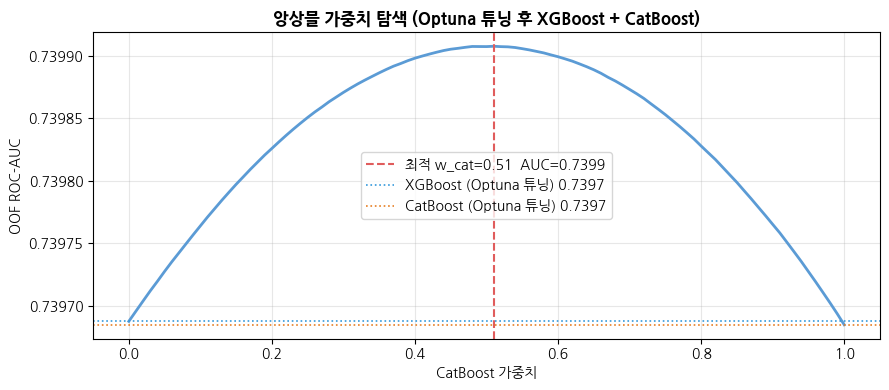

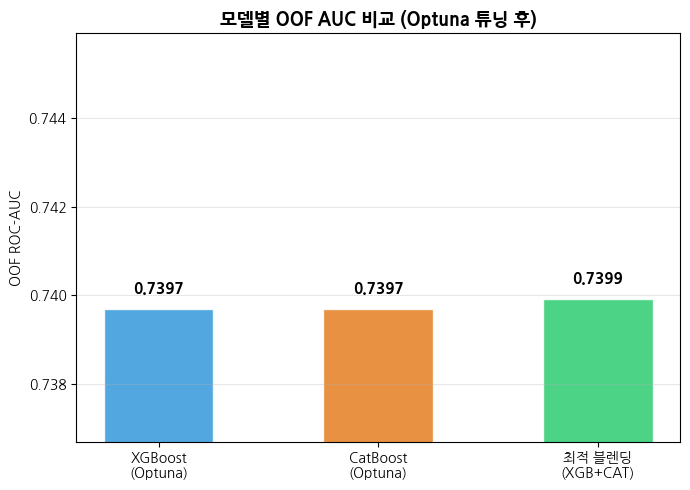

In [41]:
# ============================================================
# 12. 최적 가중치 탐색 + 시각화 (Optuna 튜닝 후 버전)
# ============================================================

# ── 앙상블 최적 가중치 탐색 (0.01 스텝으로 세분화) ──────────────
weights    = np.arange(0.0, 1.01, 0.01)
blend_aucs = [roc_auc_score(y, (1-w)*oof_xgb + w*oof_cat) for w in weights]
best_w_cat = weights[np.argmax(blend_aucs)]
best_w_xgb = 1.0 - best_w_cat
best_auc   = max(blend_aucs)
print(f'\n[최적 선형 블렌딩] XGBoost: {best_w_xgb:.2f}  CatBoost: {best_w_cat:.2f}')
print(f'앙상블 OOF AUC (최적 가중치): {best_auc:.4f}')

# 최적 가중치 기반 예측
best_blend_oof  = (1 - best_w_cat) * oof_xgb  + best_w_cat * oof_cat
best_blend_pred = (1 - best_w_cat) * pred_xgb + best_w_cat * pred_cat

# ── 가중치 탐색 곡선 ──────────────────────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(weights, blend_aucs, marker='', color='#5B9BD5', linewidth=2)
plt.axvline(best_w_cat, color='#E05C5C', linestyle='--', linewidth=1.5,
            label=f'최적 w_cat={best_w_cat:.2f}  AUC={best_auc:.4f}')
plt.axhline(auc_xgb, color='#3498db', linestyle=':', linewidth=1.2,
            label=f'XGBoost (Optuna 튜닝) {auc_xgb:.4f}')
plt.axhline(auc_cat, color='#e67e22', linestyle=':', linewidth=1.2,
            label=f'CatBoost (Optuna 튜닝) {auc_cat:.4f}')
plt.xlabel('CatBoost 가중치')
plt.ylabel('OOF ROC-AUC')
plt.title('앙상블 가중치 탐색 (Optuna 튜닝 후 XGBoost + CatBoost)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── 모델별 AUC 비교 바차트 ────────────────────────────────────
labels = ['XGBoost\n(Optuna)', 'CatBoost\n(Optuna)', '최적 블렌딩\n(XGB+CAT)']
aucs   = [auc_xgb, auc_cat, best_auc]
colors = ['#3498db', '#e67e22', '#2ecc71']

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, aucs, color=colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, a in zip(bars, aucs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0003,
             f'{a:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.ylim(min(aucs) - 0.003, max(aucs) + 0.006)
plt.ylabel('OOF ROC-AUC')
plt.title('모델별 OOF AUC 비교 (Optuna 튜닝 후)', fontweight='bold', fontsize=13)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [42]:

# ──────────────────────────────────────────────────────────
# 결과 비교 및 최종 제출
# ──────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  [Optuna 튜닝 후] XGBoost + CatBoost 앙상블 방법별 OOF AUC 비교")
print("=" * 60)

results_2 = {
    "단독 XGBoost (Optuna)"      : auc_xgb,
    "단독 CatBoost (Optuna)"     : auc_cat,
    "A. Simple Average"          : roc_auc_score(y, avg_oof_2),
    "B. OOF AUC Weighted"        : roc_auc_score(y, wavg_oof_2),
    "B-2. Optuna CV AUC Weighted": roc_auc_score(y, optuna_wavg_oof),
    "C. Stacking (LR)"           : stack_auc_2,
    "D. Rank Average"            : rank_auc_2,
    "E. 최적 선형 블렌딩"          : best_auc,
}

best_method_2 = max(results_2, key=results_2.get)
for method, auc in sorted(results_2.items(), key=lambda x: x[1], reverse=True):
    marker = "  ★ BEST" if method == best_method_2 else ""
    print(f"  {method:<30} AUC: {auc:.4f}{marker}")

# 최종 예측값 선택
best_preds_2 = {
    "단독 XGBoost (Optuna)"      : pred_xgb,
    "단독 CatBoost (Optuna)"     : pred_cat,
    "A. Simple Average"          : avg_pred_2,
    "B. OOF AUC Weighted"        : wavg_pred_2,
    "B-2. Optuna CV AUC Weighted": optuna_wavg_pred,
    "C. Stacking (LR)"           : stack_pred_2,
    "D. Rank Average"            : rank_pred_2,
    "E. 최적 선형 블렌딩"          : best_blend_pred,
}

final_pred_2 = best_preds_2[best_method_2]
print(f"\n  최종 선택 방법: {best_method_2}")

submission_2 = pd.DataFrame({
    "ID"         : test[ID_COL],
    "probability": final_pred_2,
})
submission_2.to_csv("submission_xgb_cat_ensemble_optuna.csv", index=False)
print(f"  submission_xgb_cat_ensemble_optuna.csv 저장 완료")
print(f"  예측 확률 범위 : [{final_pred_2.min():.4f}, {final_pred_2.max():.4f}]")
print(f"  예측 확률 평균 : {final_pred_2.mean():.4f}")


  [Optuna 튜닝 후] XGBoost + CatBoost 앙상블 방법별 OOF AUC 비교
  D. Rank Average                AUC: 0.7399  ★ BEST
  E. 최적 선형 블렌딩                   AUC: 0.7399
  C. Stacking (LR)               AUC: 0.7399
  B. OOF AUC Weighted            AUC: 0.7399
  A. Simple Average              AUC: 0.7399
  B-2. Optuna CV AUC Weighted    AUC: 0.7399
  단독 XGBoost (Optuna)            AUC: 0.7397
  단독 CatBoost (Optuna)           AUC: 0.7397

  최종 선택 방법: D. Rank Average
  submission_xgb_cat_ensemble_optuna.csv 저장 완료
  예측 확률 범위 : [0.0000, 1.0000]
  예측 확률 평균 : 0.5000


XGB-CAT OOF 상관계수
- 왜 모든 앙상블 방법이 동일한 AUC를 보이는가?
- 상관계수가 0.95 이상이면 두 모델이 거의 동일한 패턴을 학습한 것

In [43]:
import numpy as np
corr = np.corrcoef(oof_xgb, oof_cat)[0, 1]
print(f"XGB-CAT OOF 상관계수: {corr:.4f}")

XGB-CAT OOF 상관계수: 0.9961


In [50]:
print("=== OOF 상태 진단 ===")
print(f"oof_xgb — 0 비율: {(oof_xgb == 0).mean():.4f}, "
      f"범위: [{oof_xgb.min():.4f}, {oof_xgb.max():.4f}], "
      f"평균: {oof_xgb.mean():.4f}")
print(f"oof_cat — 0 비율: {(oof_cat == 0).mean():.4f}, "
      f"범위: [{oof_cat.min():.4f}, {oof_cat.max():.4f}], "
      f"평균: {oof_cat.mean():.4f}")
print(f"pred_xgb — 범위: [{pred_xgb.min():.4f}, {pred_xgb.max():.4f}], "
      f"평균: {pred_xgb.mean():.4f}")
print(f"pred_cat — 범위: [{pred_cat.min():.4f}, {pred_cat.max():.4f}], "
      f"평균: {pred_cat.mean():.4f}")
print(f"\nXGB-CAT OOF 상관계수: {np.corrcoef(oof_xgb, oof_cat)[0,1]:.6f}")
print(f"XGB-CAT pred 상관계수: {np.corrcoef(pred_xgb, pred_cat)[0,1]:.6f}")

=== OOF 상태 진단 ===
oof_xgb — 0 비율: 0.0000, 범위: [0.0005, 0.7705], 평균: 0.2584
oof_cat — 0 비율: 0.0000, 범위: [0.0001, 0.7625], 평균: 0.2583
pred_xgb — 범위: [0.0006, 0.7680], 평균: 0.2584
pred_cat — 범위: [0.0002, 0.7505], 평균: 0.2583

XGB-CAT OOF 상관계수: 0.996122
XGB-CAT pred 상관계수: 0.997540
